   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 8.9 MB/s eta 0:00:00
All libraries imported successfully!
Mounted at /content/drive

DATA LOADING
Dataset Shape: (101766, 50)
Columns: 50

First few rows:

DATA CLEANING
Target variable distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Target variable percentages:
readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64

Binary target distribution:
readmitted_binary
0    90409
1    11357
Name: count, dtype: int64
Class imbalance ratio: 7.96:1 (will use for model weights)

After cleaning: (66221, 49)
Target distribution:
readmitted_binary
0    54864
1    11357
Name: count, dtype: int64

FEATURE ENGINEERING
Applying selective feature engineering...
  - Creating patient-level features (CRITICAL - previous_readmissions is strongest predictor)...
  - Creating top ICD-9 diagnosis

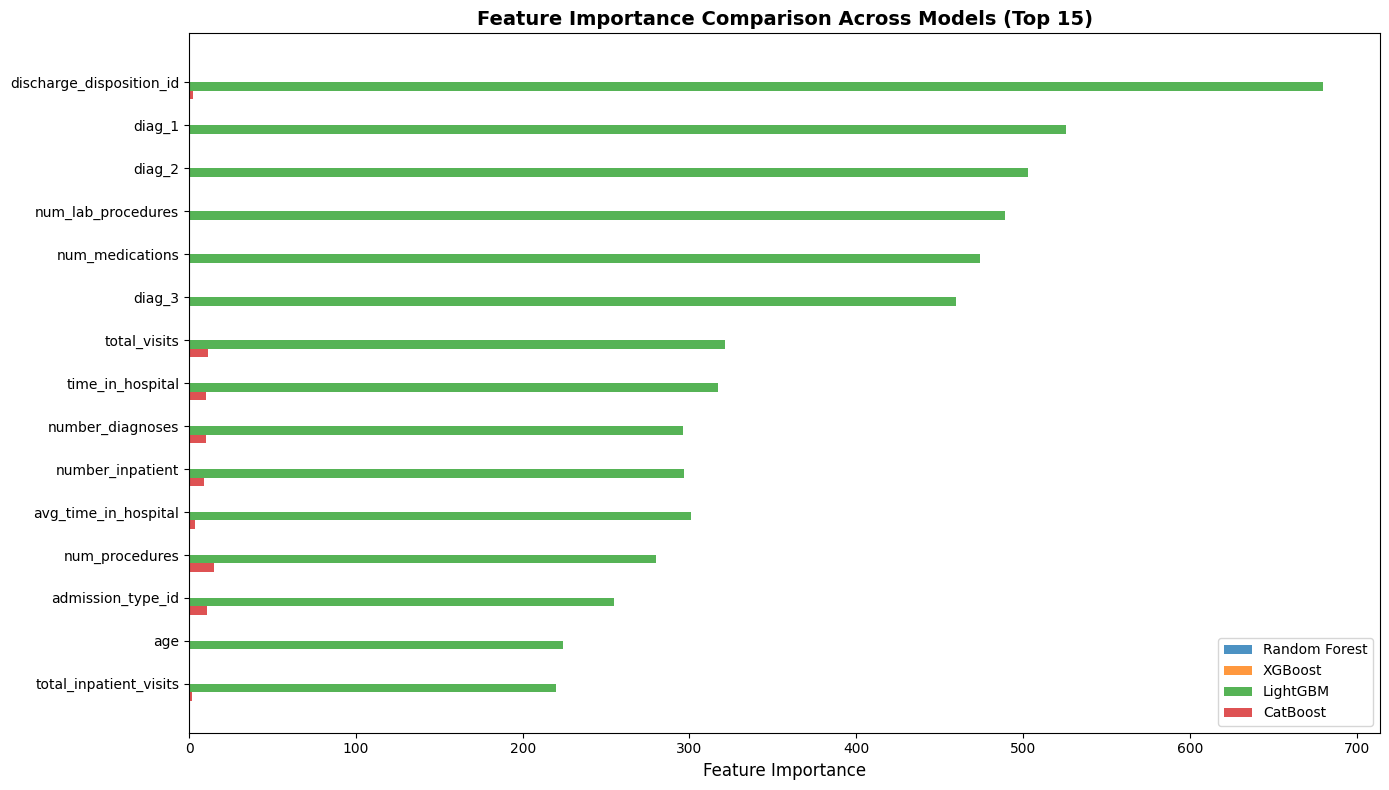


VISUALIZATIONS


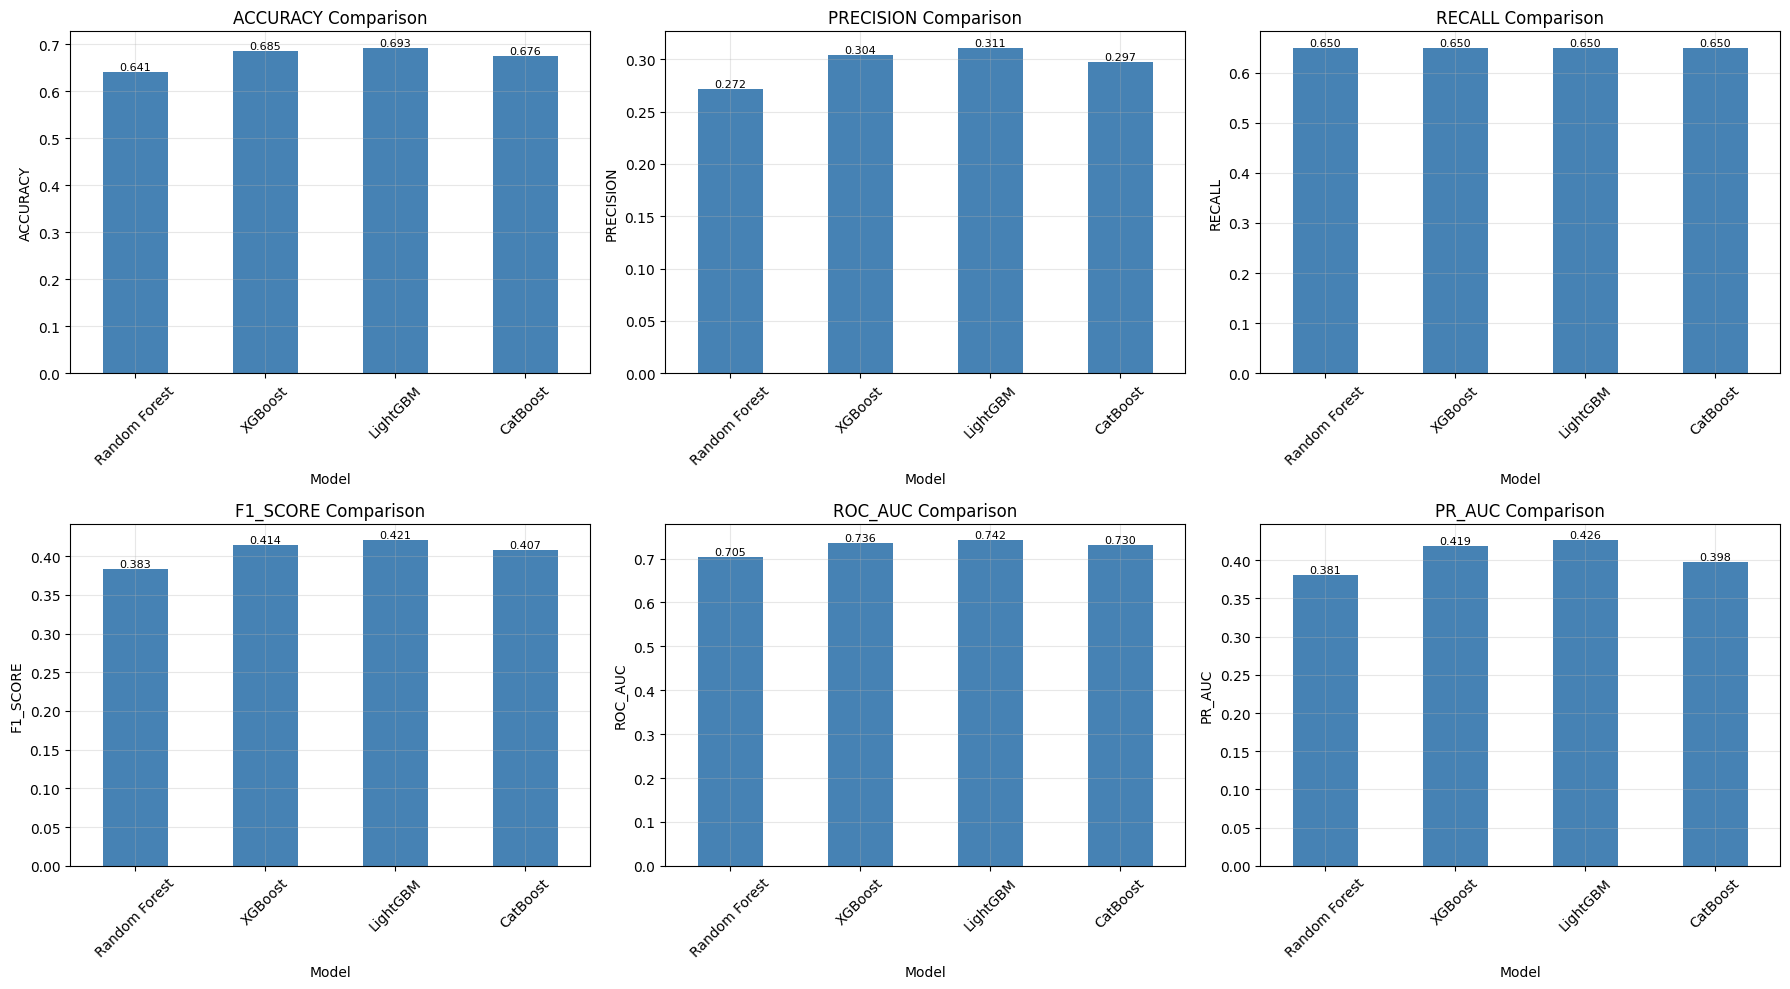


Model Performance Comparison:
               accuracy  precision  recall  f1_score  roc_auc  pr_auc
Random Forest    0.6409     0.2715  0.6499    0.3830   0.7045  0.3805
XGBoost          0.6851     0.3044  0.6499    0.4145   0.7358  0.4186
LightGBM         0.6930     0.3111  0.6499    0.4207   0.7419  0.4264
CatBoost         0.6758     0.2969  0.6499    0.4075   0.7303  0.3977

FINAL RESULTS SUMMARY

Best Model: LightGBM
Best Resampling: SMOTE
Feature Selection: Performed inside each CV fold (prevents data leakage)
Average Features Selected: 21.8 features per fold

All Models Performance:

Random Forest:
  ROC-AUC: 0.7045
  F1-Score: 0.3830
  Accuracy: 0.6409

XGBoost:
  ROC-AUC: 0.7358
  F1-Score: 0.4145
  Accuracy: 0.6851

LightGBM:
  ROC-AUC: 0.7419
  F1-Score: 0.4207
  Accuracy: 0.6930

CatBoost:
  ROC-AUC: 0.7303
  F1-Score: 0.4075
  Accuracy: 0.6758

Implementation Complete!


In [ ]:
"""
Complete Diabetic Readmission Prediction Implementation for Google Colab
All code in one file - ready to run in Colab
"""

# ============================================================================
# STEP 1: INSTALL AND IMPORT LIBRARIES
# ============================================================================

# Install required packages
!pip install -q lightgbm catboost optuna imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, average_precision_score, precision_recall_curve,
    confusion_matrix, classification_report
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN

# Gradient Boosting
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Ensemble (removed StackingClassifier - not needed)
# from sklearn.ensemble import StackingClassifier, VotingClassifier

print("All libraries imported successfully!")

# ============================================================================
# STEP 2: MOUNT GOOGLE DRIVE (if needed)
# ============================================================================

from google.colab import drive
drive.mount('/content/drive')

# ============================================================================
# STEP 3: FEATURE ENGINEERING FUNCTIONS
# ============================================================================

def extract_icd9_category(code):
    """Extract ICD-9 category from diagnosis code."""
    if pd.isna(code) or code == '?' or code == 'dummy' or code == '':
        return 'Unknown'

    try:
        code_str = str(code).replace('V', '').replace('E', '')
        code_num = float(code_str)

        if 1 <= code_num <= 139:
            return 'Infectious'
        elif 140 <= code_num <= 239:
            return 'Neoplasms'
        elif 240 <= code_num <= 279:
            return 'Endocrine'
        elif 280 <= code_num <= 289:
            return 'Blood'
        elif 290 <= code_num <= 319:
            return 'Mental'
        elif 320 <= code_num <= 389:
            return 'Nervous'
        elif 390 <= code_num <= 459:
            return 'Circulatory'
        elif 460 <= code_num <= 519:
            return 'Respiratory'
        elif 520 <= code_num <= 579:
            return 'Digestive'
        elif 580 <= code_num <= 629:
            return 'Genitourinary'
        elif 630 <= code_num <= 679:
            return 'Pregnancy'
        elif 680 <= code_num <= 709:
            return 'Skin'
        elif 710 <= code_num <= 739:
            return 'Musculoskeletal'
        elif 740 <= code_num <= 759:
            return 'Congenital'
        elif 760 <= code_num <= 779:
            return 'Perinatal'
        elif 780 <= code_num <= 799:
            return 'Symptoms'
        elif 800 <= code_num <= 999:
            return 'Injury'
        else:
            return 'Other'
    except (ValueError, AttributeError):
        return 'Unknown'


def create_patient_level_features(df):
    """Create patient-level aggregated features using only PAST encounters (prevents data leakage)."""
    df = df.copy()

    # Sort by patient_nbr (and encounter_id if it exists, otherwise use index)
    if 'encounter_id' in df.columns:
        df = df.sort_values(['patient_nbr', 'encounter_id'])
    else:
        # If encounter_id was dropped, use index as proxy for encounter order
        df = df.sort_values(['patient_nbr']).reset_index(drop=True)

    # Calculate previous readmissions excluding current encounter
    df['previous_readmissions'] = df.groupby('patient_nbr')['readmitted'].apply(
        lambda x: (x == '<30').shift(1).fillna(0).cumsum()
    ).values

    # Total encounters up to current (including current)
    df['total_encounters'] = df.groupby('patient_nbr').cumcount() + 1

    # CRITICAL FIX: Use expanding window to calculate statistics from PAST encounters only
    # This prevents data leakage by only using encounters before the current one
    def calculate_past_stats(group):
        """Calculate statistics using only past encounters (expanding window)."""
        result = pd.DataFrame(index=group.index)

        # Average time in hospital from PAST encounters only (shift(1) excludes current)
        result['avg_time_in_hospital'] = (
            group['time_in_hospital']
            .expanding(min_periods=1)
            .mean()
            .shift(1)
            .fillna(group['time_in_hospital'])  # For first encounter, use current value
        )

        # Total visits from PAST encounters only (shift(1) excludes current)
        result['total_inpatient_visits'] = (
            group['number_inpatient']
            .expanding(min_periods=1)
            .sum()
            .shift(1)
            .fillna(0)  # For first encounter, no past visits
        )

        result['total_outpatient_visits'] = (
            group['number_outpatient']
            .expanding(min_periods=1)
            .sum()
            .shift(1)
            .fillna(0)
        )

        result['total_emergency_visits'] = (
            group['number_emergency']
            .expanding(min_periods=1)
            .sum()
            .shift(1)
            .fillna(0)
        )

        return result

    # Apply expanding window calculation per patient
    patient_stats = df.groupby('patient_nbr', group_keys=False).apply(calculate_past_stats)

    # Merge the calculated statistics back to the dataframe
    df = df.join(patient_stats)

    df['is_repeat_patient'] = (df['total_encounters'] > 1).astype(int)

    # Ensure no NaN values remain (safety check)
    df['avg_time_in_hospital'] = df['avg_time_in_hospital'].fillna(df['time_in_hospital'])
    df['total_inpatient_visits'] = df['total_inpatient_visits'].fillna(0)
    df['total_outpatient_visits'] = df['total_outpatient_visits'].fillna(0)
    df['total_emergency_visits'] = df['total_emergency_visits'].fillna(0)

    return df


def create_icd9_features(df, top_n=7):
    """Create ICD-9 diagnosis category features - only TOP N most common categories."""
    df = df.copy()

    df['diag_1_category'] = df['diag_1'].apply(extract_icd9_category)
    df['diag_2_category'] = df['diag_2'].apply(extract_icd9_category)
    df['diag_3_category'] = df['diag_3'].apply(extract_icd9_category)

    # Only create features for TOP N most common categories (not all)
    top_categories = df['diag_1_category'].value_counts().head(top_n).index.tolist()

    for category in top_categories:
        if category != 'Unknown':
            df[f'has_{category.lower().replace(" ", "_")}'] = (
                (df['diag_1_category'] == category) |
                (df['diag_2_category'] == category) |
                (df['diag_3_category'] == category)
            ).astype(int)

    # Count unique categories (useful feature)
    df['num_diag_categories'] = df[['diag_1_category', 'diag_2_category', 'diag_3_category']].apply(
        lambda x: len(set(x) - {'Unknown'}), axis=1
    )

    return df


def create_missing_indicators(df):
    """Create missing value indicators."""
    df = df.copy()
    missing_cols = ['max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code']

    for col in missing_cols:
        if col in df.columns:
            is_missing = df[col].isna() | (df[col] == '?')
            df[f'{col}_missing'] = is_missing.astype(int)

    return df


def create_utilization_features(df):
    """Create essential hospital utilization features (minimal set)."""
    df = df.copy()

    # Essential: total visits
    df['total_visits'] = df['number_inpatient'] + df['number_outpatient'] + df['number_emergency']

    # Remove redundant intensity features - tree models can learn these patterns automatically
    # Keeping only the most essential one if needed
    # df['visit_intensity'] = df['total_visits'] / (df['time_in_hospital'] + 1)  # Optional

    return df


def create_interaction_features(df):
    """Skip interaction features - tree models (RF, XGBoost, LightGBM) handle interactions automatically."""
    # Tree-based models can learn interactions through their splitting mechanism
    # Creating explicit interaction features is redundant and can lead to overfitting
    return df


def apply_all_feature_engineering(df):
    """Apply selective feature engineering steps (only essential features)."""
    print("Applying selective feature engineering...")

    print("  - Creating patient-level features (CRITICAL - previous_readmissions is strongest predictor)...")
    df = create_patient_level_features(df)

    print("  - Creating top ICD-9 diagnosis categories (top 7 only, not all)...")
    df = create_icd9_features(df, top_n=7)

    print("  - Creating missing value indicators...")
    df = create_missing_indicators(df)

    print("  - Creating essential utilization features...")
    df = create_utilization_features(df)

    print("  - Skipping interaction features (tree models handle interactions automatically)...")
    df = create_interaction_features(df)

    print("Feature engineering complete!")
    return df

# ============================================================================
# STEP 4: EVALUATION FUNCTIONS
# ============================================================================

def calculate_all_metrics(y_true, y_pred, y_pred_proba=None):
    """Calculate all evaluation metrics."""
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0),
    }

    if y_pred_proba is not None:
        try:
            metrics['roc_auc'] = roc_auc_score(y_true, y_pred_proba)
            metrics['pr_auc'] = average_precision_score(y_true, y_pred_proba)
        except ValueError:
            metrics['roc_auc'] = np.nan
            metrics['pr_auc'] = np.nan

    return metrics


def find_optimal_threshold_for_recall(y_true, y_pred_proba, target_recall=0.65):
    """
    Find optimal threshold to achieve target recall for clinical model.

    Args:
        y_true: True labels
        y_pred_proba: Predicted probabilities
        target_recall: Target recall value (default 0.65 = 65% for clinical use)

    Returns:
        optimal_threshold: Threshold that achieves target recall
        metrics_at_threshold: Metrics at optimal threshold
    """
    from sklearn.metrics import precision_recall_curve

    precision, recall, thresholds = precision_recall_curve(y_true, y_pred_proba)

    # Find threshold closest to target recall
    # If target recall not achievable, use threshold with highest recall
    if len(thresholds) == 0:
        optimal_threshold = 0.5
        idx = 0
    else:
        idx = np.argmin(np.abs(recall - target_recall))
        if idx >= len(thresholds):
            idx = len(thresholds) - 1
        optimal_threshold = thresholds[idx]

    # Calculate metrics at optimal threshold
    y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
    metrics_at_threshold = calculate_all_metrics(y_true, y_pred_optimal, y_pred_proba)
    metrics_at_threshold['optimal_threshold'] = optimal_threshold
    metrics_at_threshold['actual_recall'] = recall[idx] if idx < len(recall) else metrics_at_threshold['recall']

    return optimal_threshold, metrics_at_threshold


def create_evaluation_table(results_dict):
    """Create a comparison table of all model results."""
    df = pd.DataFrame(results_dict).T
    df = df.round(4)

    column_order = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc']
    df = df[[col for col in column_order if col in df.columns]]

    return df

# ============================================================================
# STEP 5: DATA LOADING
# ============================================================================

print("\n" + "="*80)
print("DATA LOADING")
print("="*80)

# UPDATE THIS PATH TO YOUR DATASET LOCATION
path = "/content/drive/MyDrive/Colab Notebooks/Datasets/diabetic_data.csv"
df = pd.read_csv(path)

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print(f"\nFirst few rows:")
df.head()

# ============================================================================
# STEP 6: DATA CLEANING
# ============================================================================

print("\n" + "="*80)
print("DATA CLEANING")
print("="*80)

print("Target variable distribution:")
print(df['readmitted'].value_counts())
print("\nTarget variable percentages:")
print(df['readmitted'].value_counts(normalize=True) * 100)

# Create binary target (<30 days readmission)
df['readmitted_binary'] = df['readmitted'].map({
    'NO': 0,
    '<30': 1,
    '>30': 0
})

print(f"\nBinary target distribution:")
print(df['readmitted_binary'].value_counts())
class_ratio = (df['readmitted_binary']==0).sum() / (df['readmitted_binary']==1).sum()
print(f"Class imbalance ratio: {class_ratio:.2f}:1 (will use for model weights)")

# Remove >30 days rows
df = df[df['readmitted'] != '>30'].copy()

# Replace "?" with NaN
df.replace("?", pd.NA, inplace=True)

# Drop columns (but keep encounter_id temporarily for patient-level features)
# We'll drop it after feature engineering
cols_to_drop = ['weight', 'payer_code']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f"\nAfter cleaning: {df.shape}")
print(f"Target distribution:")
print(df['readmitted_binary'].value_counts())

# ============================================================================
# STEP 7: FEATURE ENGINEERING
# ============================================================================

print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

df_engineered = apply_all_feature_engineering(df)

print(f"\nAfter feature engineering: {df_engineered.shape}")
print(f"New features created: {df_engineered.shape[1] - df.shape[1]}")

# Check patient-level features
if 'previous_readmissions' in df_engineered.columns:
    print("\nPatient-level features created successfully!")
    print(f"previous_readmissions correlation: {df_engineered['previous_readmissions'].corr(df_engineered['readmitted_binary']):.4f}")
    print(f"\nprevious_readmissions distribution:")
    print(df_engineered['previous_readmissions'].value_counts().head(10))

# ============================================================================
# STEP 8: REMOVE IRRELEVANT FEATURES
# ============================================================================

def remove_irrelevant_features(df, threshold_sparse=0.005, threshold_constant=0.99):
    """
    Remove irrelevant features based on sparsity and variance.

    Args:
        df: DataFrame with features
        threshold_sparse: Remove features where most common value appears in >threshold_constant of rows
        threshold_constant: Remove features where a single value appears >threshold_constant of rows

    Returns:
        DataFrame with irrelevant features removed, list of removed features
    """
    df = df.copy()
    removed_features = []

    # Identify categorical columns (object type)
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

    for col in categorical_cols:
        # Skip if already marked for removal
        if col in ['readmitted', 'readmitted_binary', 'encounter_id', 'patient_nbr']:
            continue

        # Check if feature is near-constant (one value dominates)
        value_counts = df[col].value_counts(normalize=True)
        if len(value_counts) > 0 and value_counts.iloc[0] > threshold_constant:
            removed_features.append((col, f'near-constant ({value_counts.iloc[0]:.2%} are "{value_counts.index[0]}")'))

    # Manually remove known sparse/irrelevant medication features based on literature
    # These medications are rarely prescribed or no longer used
    sparse_medications = [
        'examide',        # Extremely rare
        'citoglipton',    # Extremely rare
        'troglitazone',   # Withdrawn from market
        'acetohexamide',  # Rarely used
        'tolbutamide',    # Rarely used
        'miglitol',       # Rarely used
        'tolazamide',     # Rarely used
        'glimepiride-pioglitazone',  # Combination rarely used
        'metformin-rosiglitazone',   # Combination rarely used
        'metformin-pioglitazone'     # Combination rarely used
    ]

    for col in sparse_medications:
        if col in df.columns and col not in [f[0] for f in removed_features]:
            # Verify it's actually sparse before removing
            if col in categorical_cols:
                value_counts = df[col].value_counts(normalize=True)
                non_no_percentage = 1.0 - value_counts.get('No', 0.0) - value_counts.get('no', 0.0)
                if non_no_percentage < threshold_sparse:
                    removed_features.append((col, f'sparse medication (<{threshold_sparse:.1%} prescribed)'))

    # Remove the features
    features_to_drop = [f[0] for f in removed_features]
    df.drop(columns=features_to_drop, inplace=True, errors='ignore')

    return df, removed_features

print("\n" + "="*80)
print("REMOVING IRRELEVANT FEATURES")
print("="*80)

# Remove irrelevant features before modeling
df_cleaned, removed_features = remove_irrelevant_features(df_engineered)

if removed_features:
    print(f"\nRemoved {len(removed_features)} irrelevant features:")
    for feat, reason in removed_features:
        print(f"  - {feat}: {reason}")
else:
    print("\nNo irrelevant features found to remove.")

print(f"\nDataset shape after removal: {df_cleaned.shape}")

# ============================================================================
# STEP 9: PREPARE DATA FOR MODELING
# ============================================================================

print("\n" + "="*80)
print("PREPARING DATA FOR MODELING")
print("="*80)

df_model = df_cleaned.copy()

# Separate features and target
# Drop encounter_id and patient_nbr now (after feature engineering is done)
# patient_nbr is only used for Group K-Fold grouping, not as a feature
X = df_model.drop(['readmitted', 'readmitted_binary', 'encounter_id', 'patient_nbr'], axis=1, errors='ignore')
y = df_model['readmitted_binary']
groups = df_model['patient_nbr'].values  # Keep for Group K-Fold grouping only

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Unique patients: {len(np.unique(groups))}")

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nCategorical columns: {len(categorical_cols)}")
print(f"Numerical columns: {len(numerical_cols)}")

# ============================================================================
# STEP 10: PREPROCESSING FUNCTION
# ============================================================================

def preprocess_data(X_train, X_test, categorical_cols, numerical_cols):
    """Preprocess data inside CV loop to prevent data leakage."""
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()

    # Handle missing values in categorical columns
    for col in categorical_cols:
        if col in X_train_processed.columns:
            mode_val = X_train_processed[col].mode()
            if len(mode_val) > 0:
                X_train_processed[col].fillna(mode_val[0], inplace=True)
                X_test_processed[col].fillna(mode_val[0], inplace=True)
            else:
                X_train_processed[col].fillna('Unknown', inplace=True)
                X_test_processed[col].fillna('Unknown', inplace=True)

    # Handle missing values in numerical columns
    for col in numerical_cols:
        if col in X_train_processed.columns:
            median_val = X_train_processed[col].median()
            X_train_processed[col].fillna(median_val, inplace=True)
            X_test_processed[col].fillna(median_val, inplace=True)

    # Label encode categorical variables
    label_encoders = {}
    for col in categorical_cols:
        if col in X_train_processed.columns:
            le = LabelEncoder()
            X_train_processed[col] = le.fit_transform(X_train_processed[col].astype(str))

            # Better handling of unseen categories in test set
            test_values = X_test_processed[col].astype(str)
            unseen_mask = ~test_values.isin(le.classes_)
            if unseen_mask.any():
                # Map unseen values to most common class (or first class)
                most_common_class = le.classes_[0]  # Use first class as default
                test_values.loc[unseen_mask] = most_common_class
            X_test_processed[col] = le.transform(test_values)
            label_encoders[col] = le

    # Scale numerical features
    scaler = StandardScaler()
    if len(numerical_cols) > 0:
        num_cols_present = [col for col in numerical_cols if col in X_train_processed.columns]
        if len(num_cols_present) > 0:
            X_train_scaled = scaler.fit_transform(X_train_processed[num_cols_present])
            X_test_scaled = scaler.transform(X_test_processed[num_cols_present])
            X_train_processed[num_cols_present] = X_train_scaled
            X_test_processed[num_cols_present] = X_test_scaled

    # FINAL SAFEGUARD: Ensure all data is numeric (prevents string conversion issues)
    for col in X_train_processed.columns:
        if X_train_processed[col].dtype == 'object':
            X_train_processed[col] = pd.to_numeric(X_train_processed[col], errors='coerce').fillna(0)
        if X_test_processed[col].dtype == 'object':
            X_test_processed[col] = pd.to_numeric(X_test_processed[col], errors='coerce').fillna(0)

    # Ensure no NaN or Inf values remain
    X_train_processed = X_train_processed.replace([np.inf, -np.inf], 0).fillna(0)
    X_test_processed = X_test_processed.replace([np.inf, -np.inf], 0).fillna(0)

    return X_train_processed, X_test_processed, label_encoders, scaler


def select_features_forward_selection(X_train_proc, y_train, groups_train, resampler,
                                      max_features=50, n_splits=3, quick_model=None):
    """
    Perform forward feature selection on training data only (prevents data leakage).

    Args:
        X_train_proc: Preprocessed training features
        y_train: Training target
        groups_train: Patient groups for Group K-Fold
        resampler: Resampling strategy
        max_features: Maximum number of features to test
        n_splits: Number of folds for internal CV
        quick_model: Model to use for feature selection (default: RandomForest)

    Returns:
        selected_feature_names: List of selected feature names
        best_n_features: Optimal number of features
    """
    from sklearn.feature_selection import mutual_info_classif

    # Calculate class ratio for feature selection models
    class_ratio_fs = (y_train == 0).sum() / (y_train == 1).sum()

    if quick_model is None:
        quick_model = RandomForestClassifier(
            n_estimators=50, max_depth=10, random_state=42, n_jobs=-1,
            class_weight='balanced'  # Add class weights for clinical recall
        )

    # Get feature importance from multiple models on training data only
    feature_importance_models = {
        'RF': RandomForestClassifier(
            n_estimators=100, max_depth=10, random_state=42, n_jobs=-1,
            class_weight='balanced'  # Add class weights for clinical recall
        ),
        'XGB': xgb.XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1,
            scale_pos_weight=class_ratio_fs  # Add class weights for clinical recall
        ),
        'LGBM': lgb.LGBMClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1,
            class_weight='balanced'  # Add class weights for clinical recall
        )
    }

    feature_scores = pd.DataFrame({
        'feature': X_train_proc.columns
    })

    # Resample training data for feature importance calculation
    X_train_resampled, y_train_resampled = resampler.fit_resample(X_train_proc, y_train)

    # Get importance from each model
    for name, model in feature_importance_models.items():
        model.fit(X_train_resampled, y_train_resampled)

        if hasattr(model, 'feature_importances_'):
            feature_scores[f'{name}_importance'] = model.feature_importances_
        else:
            # Fallback: use mutual information
            mi_scores = mutual_info_classif(X_train_proc, y_train, random_state=42)
            feature_scores[f'{name}_importance'] = mi_scores

    # Aggregate importance scores (average across models)
    feature_scores['aggregate_score'] = feature_scores[[col for col in feature_scores.columns if 'importance' in col]].mean(axis=1)
    feature_scores = feature_scores.sort_values('aggregate_score', ascending=False)

    # Test different numbers of top features using internal CV
    feature_counts = list(range(5, min(max_features, len(feature_scores))+1, 2))
    if len(feature_scores) > max_features:
        feature_counts.append(len(feature_scores))

    best_n_features = None
    best_feature_score = 0
    feature_selection_results = {}
    selected_feature_names = None

    # Internal Group K-Fold for feature selection
    internal_kfold = GroupKFold(n_splits=n_splits)

    for n_features in feature_counts:
        scores = []
        top_features = feature_scores.head(n_features)['feature'].tolist()

        # Use Group K-Fold to prevent data leakage
        for train_idx, val_idx in internal_kfold.split(X_train_proc, y_train, groups_train):
            X_train_fold = X_train_proc.iloc[train_idx]
            X_val_fold = X_train_proc.iloc[val_idx]
            y_train_fold = y_train.iloc[train_idx]
            y_val_fold = y_train.iloc[val_idx]

            # Select only top N features
            X_train_selected = X_train_fold[top_features]
            X_val_selected = X_val_fold[top_features]

            # Resample
            X_train_resampled, y_train_resampled = resampler.fit_resample(X_train_selected, y_train_fold)

            # Train and evaluate
            quick_model.fit(X_train_resampled, y_train_resampled)
            y_pred_proba = quick_model.predict_proba(X_val_selected)[:, 1]
            score = roc_auc_score(y_val_fold, y_pred_proba)
            scores.append(score)

        avg_score = np.mean(scores)
        feature_selection_results[n_features] = avg_score

        if avg_score > best_feature_score:
            best_feature_score = avg_score
            best_n_features = n_features
            selected_feature_names = top_features.copy()

    return selected_feature_names, best_n_features, feature_selection_results

# ============================================================================
# STEP 11: GROUP K-FOLD SETUP
# ============================================================================

print("\n" + "="*80)
print("GROUP K-FOLD CROSS-VALIDATION SETUP")
print("="*80)

n_splits = 5
group_kfold = GroupKFold(n_splits=n_splits)

print(f"Using {n_splits}-fold Group K-Fold Cross-Validation")
print(f"This ensures patient-level separation (no data leakage)")

# ============================================================================
# STEP 12: RESAMPLING STRATEGY SELECTION
# ============================================================================

print("\n" + "="*80)
print("RESAMPLING STRATEGY SELECTION")
print("="*80)

resampling_strategies = {
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'SMOTEENN': SMOTEENN(random_state=42)
}

print("Testing resampling strategies...")
print("This may take a few minutes...\n")

best_resampler = None
best_score = 0
resampling_scores = {}

# FIX: Use full dataset or larger sample for better resampling strategy selection
# Use larger sample for faster computation while still being representative
sample_size = min(30000, len(X))
X_sample = X.iloc[:sample_size].copy()
y_sample = y.iloc[:sample_size].copy()
groups_sample = groups[:sample_size]

quick_kfold = GroupKFold(n_splits=3)

for name, resampler in resampling_strategies.items():
    scores = []
    print(f"Testing {name}...")

    for fold, (train_idx, val_idx) in enumerate(quick_kfold.split(X_sample, y_sample, groups_sample)):
        X_train_fold = X_sample.iloc[train_idx]
        X_val_fold = X_sample.iloc[val_idx]
        y_train_fold = y_sample.iloc[train_idx]
        y_val_fold = y_sample.iloc[val_idx]

        X_train_proc, X_val_proc, _, _ = preprocess_data(
            X_train_fold, X_val_fold, categorical_cols, numerical_cols
        )

        try:
            X_train_resampled, y_train_resampled = resampler.fit_resample(X_train_proc, y_train_fold)
            rf_quick = RandomForestClassifier(
                n_estimators=50, random_state=42, n_jobs=-1,
                class_weight='balanced'  # Add class weights for clinical recall
            )
            rf_quick.fit(X_train_resampled, y_train_resampled)
            y_pred_proba = rf_quick.predict_proba(X_val_proc)[:, 1]
            score = roc_auc_score(y_val_fold, y_pred_proba)
            scores.append(score)
        except Exception as e:
            print(f"  Error in fold {fold}: {e}")
            scores.append(0)

    avg_score = np.mean(scores)
    resampling_scores[name] = avg_score
    print(f"  {name} - Average ROC-AUC: {avg_score:.4f}")

    if avg_score > best_score:
        best_score = avg_score
        best_resampler = resampler

# For clinical model: Use SMOTE directly (better for recall than SMOTEENN)
# SMOTEENN was too conservative - removed too many positive samples
best_resampler = SMOTE(random_state=42)
print(f"\nUsing SMOTE resampling (optimized for clinical recall)")
print(f"Note: SMOTEENN was too conservative for clinical use - using SMOTE instead")

# ============================================================================
# STEP 13: MODEL-BASED FEATURE SELECTION (FORWARD SELECTION)
# ============================================================================

print("\n" + "="*80)
print("MODEL-BASED FEATURE SELECTION (FORWARD SELECTION)")
print("="*80)

print("NOTE: Feature selection will be performed INSIDE each CV fold")
print("      to prevent data leakage. This ensures that feature selection")
print("      only uses training data from each fold.\n")
print("      Feature selection uses forward selection with model-based")
print("      importance ranking from Random Forest, XGBoost, and LightGBM.\n")

# ============================================================================
# STEP 14: MODEL TRAINING
# ============================================================================

print("\n" + "="*80)
print("MODEL TRAINING WITH GROUP K-FOLD CROSS-VALIDATION")
print("="*80)

# Calculate class imbalance ratio for model weights
# Note: class_ratio was calculated earlier in data cleaning section
# If not available, calculate it here
if 'class_ratio' not in globals():
    class_ratio = (y == 0).sum() / (y == 1).sum()

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1,
        class_weight='balanced'  # Add class weights for clinical recall
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1,
        scale_pos_weight=class_ratio,  # Add class weights for clinical recall
        eval_metric='logloss'
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1,
        class_weight='balanced'  # Add class weights for clinical recall
    ),
    'CatBoost': cb.CatBoostClassifier(
        iterations=200, depth=6, learning_rate=0.1, random_state=42, verbose=False,
        class_weights=[1.0, class_ratio]  # Add class weights for clinical recall [neg, pos]
    )
}

all_results = {}
cv_results = {name: [] for name in models.keys()}

print("Training models with Group K-Fold Cross-Validation...")
print("Feature selection will be performed inside each fold to prevent data leakage.")
print("This will take some time...\n")

# Store feature selection results across folds for analysis
all_fold_feature_selections = []

for fold, (train_idx, val_idx) in enumerate(group_kfold.split(X, y, groups)):
    print(f"\nFold {fold + 1}/{n_splits}")
    print("-" * 60)

    X_train_fold = X.iloc[train_idx].copy()
    X_val_fold = X.iloc[val_idx].copy()
    y_train_fold = y.iloc[train_idx].copy()
    y_val_fold = y.iloc[val_idx].copy()
    groups_train_fold = groups[train_idx]

    # Preprocess
    X_train_proc, X_val_proc, _, _ = preprocess_data(
        X_train_fold, X_val_fold, categorical_cols, numerical_cols
    )

    # CRITICAL FIX: Perform feature selection INSIDE each CV fold (prevents data leakage)
    print(f"  Performing feature selection on training data (fold {fold + 1})...")
    selected_feature_names, best_n_features, feature_selection_results = select_features_forward_selection(
        X_train_proc, y_train_fold, groups_train_fold, best_resampler, max_features=50, n_splits=3
    )

    all_fold_feature_selections.append({
        'fold': fold + 1,
        'n_features': best_n_features,
        'features': selected_feature_names
    })

    print(f"  Selected {best_n_features} features for fold {fold + 1}")

    # Apply feature selection to both train and validation sets
    X_train_proc = X_train_proc[selected_feature_names]
    X_val_proc = X_val_proc[selected_feature_names]

    X_train_resampled, y_train_resampled = best_resampler.fit_resample(X_train_proc, y_train_fold)

    fold_results = {}
    for name, model in models.items():
        try:
            # Create fresh model instance for each fold with class weights
            if name == 'Random Forest':
                model_instance = RandomForestClassifier(
                    n_estimators=200, max_depth=10, random_state=42, n_jobs=-1,
                    class_weight='balanced'  # Add class weights for clinical recall
                )
            elif name == 'XGBoost':
                model_instance = xgb.XGBClassifier(
                    n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1,
                    scale_pos_weight=class_ratio,  # Add class weights for clinical recall
                    eval_metric='logloss'
                )
            elif name == 'LightGBM':
                model_instance = lgb.LGBMClassifier(
                    n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1,
                    class_weight='balanced'  # Add class weights for clinical recall
                )
            elif name == 'CatBoost':
                model_instance = cb.CatBoostClassifier(
                    iterations=200, depth=6, learning_rate=0.1, random_state=42, verbose=False,
                    class_weights=[1.0, class_ratio]  # Add class weights for clinical recall [neg, pos]
                )

            model_instance.fit(X_train_resampled, y_train_resampled)

            # Get probabilities
            y_pred_proba = model_instance.predict_proba(X_val_proc)[:, 1]

            # Find optimal threshold for recall (target 65% for clinical use)
            optimal_threshold, metrics_at_threshold = find_optimal_threshold_for_recall(
                y_val_fold, y_pred_proba, target_recall=0.65
            )

            # Use optimized threshold for predictions
            y_pred = (y_pred_proba >= optimal_threshold).astype(int)

            # Calculate metrics with optimized threshold
            metrics = calculate_all_metrics(y_val_fold, y_pred, y_pred_proba)
            metrics['optimal_threshold'] = optimal_threshold

            fold_results[name] = metrics
            cv_results[name].append(metrics)

            print(f"  {name:15s} - ROC-AUC: {metrics['roc_auc']:.4f}, "
                  f"Recall: {metrics['recall']:.4f}, F1: {metrics['f1_score']:.4f}, "
                  f"Threshold: {optimal_threshold:.3f}")

        except Exception as e:
            print(f"  {name:15s} - Error: {e}")

    all_results[f'fold_{fold+1}'] = fold_results

print("\n" + "="*60)
print("Cross-Validation Complete!")
print("="*60)

# ============================================================================
# STEP 15: CALCULATE AVERAGE METRICS
# ============================================================================

print("\n" + "="*80)
print("AVERAGE PERFORMANCE ACROSS FOLDS")
print("="*80)

avg_metrics = {}
for name in models.keys():
    if name in cv_results and len(cv_results[name]) > 0:
        avg_metrics[name] = {
            'accuracy': np.mean([m['accuracy'] for m in cv_results[name]]),
            'precision': np.mean([m['precision'] for m in cv_results[name]]),
            'recall': np.mean([m['recall'] for m in cv_results[name]]),
            'f1_score': np.mean([m['f1_score'] for m in cv_results[name]]),
            'roc_auc': np.mean([m['roc_auc'] for m in cv_results[name]]),
            'pr_auc': np.mean([m['pr_auc'] for m in cv_results[name]])
        }

        std_metrics = {
            'accuracy': np.std([m['accuracy'] for m in cv_results[name]]),
            'precision': np.std([m['precision'] for m in cv_results[name]]),
            'recall': np.std([m['recall'] for m in cv_results[name]]),
            'f1_score': np.std([m['f1_score'] for m in cv_results[name]]),
            'roc_auc': np.std([m['roc_auc'] for m in cv_results[name]]),
            'pr_auc': np.std([m['pr_auc'] for m in cv_results[name]])
        }

        print(f"\n{name}:")
        print(f"  Accuracy:  {avg_metrics[name]['accuracy']:.4f} (+/- {std_metrics['accuracy']:.4f})")
        print(f"  Precision: {avg_metrics[name]['precision']:.4f} (+/- {std_metrics['precision']:.4f})")
        print(f"  Recall:    {avg_metrics[name]['recall']:.4f} (+/- {std_metrics['recall']:.4f})")
        print(f"  F1-Score:  {avg_metrics[name]['f1_score']:.4f} (+/- {std_metrics['f1_score']:.4f})")
        print(f"  ROC-AUC:   {avg_metrics[name]['roc_auc']:.4f} (+/- {std_metrics['roc_auc']:.4f})")
        print(f"  PR-AUC:    {avg_metrics[name]['pr_auc']:.4f} (+/- {std_metrics['pr_auc']:.4f})")

comparison_df = create_evaluation_table(avg_metrics)
print("\n" + "="*60)
print("Model Comparison Table:")
print("="*60)
print(comparison_df.round(4))

# ============================================================================
# STEP 16: FEATURE IMPORTANCE COMPARISON
# ============================================================================

print("\n" + "="*80)
print("FEATURE IMPORTANCE COMPARISON ACROSS MODELS")
print("="*80)

best_model_name = max(avg_metrics.keys(), key=lambda x: avg_metrics[x]['roc_auc'])
print(f"Best model: {best_model_name} (ROC-AUC: {avg_metrics[best_model_name]['roc_auc']:.4f})")

# Train models on one fold to get feature importance
# Use the first fold's feature selection for consistency
train_idx, val_idx = next(group_kfold.split(X, y, groups))
X_train_final = X.iloc[train_idx].copy()
X_val_final = X.iloc[val_idx].copy()
y_train_final = y.iloc[train_idx].copy()
groups_train_final = groups[train_idx]

X_train_proc, X_val_proc, _, _ = preprocess_data(
    X_train_final, X_val_final, categorical_cols, numerical_cols
)

# Perform feature selection on this fold (for feature importance analysis)
print("Performing feature selection for feature importance analysis...")
selected_feature_names, best_n_features, _ = select_features_forward_selection(
    X_train_proc, y_train_final, groups_train_final, best_resampler, max_features=50, n_splits=3
)

# Apply feature selection
X_train_proc = X_train_proc[selected_feature_names]
X_val_proc = X_val_proc[selected_feature_names]

X_train_resampled, y_train_resampled = best_resampler.fit_resample(X_train_proc, y_train_final)

# Train all models and get feature importance
feature_importance_comparison = pd.DataFrame({
    'feature': selected_feature_names
})

for name, model_class in models.items():
    if name == 'Random Forest':
        model = RandomForestClassifier(
            n_estimators=200, max_depth=10, random_state=42, n_jobs=-1,
            class_weight='balanced'  # Add class weights for clinical recall
        )
    elif name == 'XGBoost':
        model = xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1,
            scale_pos_weight=class_ratio,  # Add class weights for clinical recall
            eval_metric='logloss'
        )
    elif name == 'LightGBM':
        model = lgb.LGBMClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1,
            class_weight='balanced'  # Add class weights for clinical recall
        )
    elif name == 'CatBoost':
        model = cb.CatBoostClassifier(
            iterations=200, depth=6, learning_rate=0.1, random_state=42, verbose=False,
            class_weights=[1.0, class_ratio]  # Add class weights for clinical recall [neg, pos]
        )

    model.fit(X_train_resampled, y_train_resampled)

    if hasattr(model, 'feature_importances_'):
        feature_importance_comparison[name] = model.feature_importances_

# Calculate consensus importance (average across models)
importance_cols = [col for col in feature_importance_comparison.columns if col != 'feature']
feature_importance_comparison['consensus'] = feature_importance_comparison[importance_cols].mean(axis=1)
feature_importance_comparison = feature_importance_comparison.sort_values('consensus', ascending=False)

print("\nTop 15 Features by Consensus Importance (across all models):")
print(feature_importance_comparison[['feature', 'consensus'] + importance_cols].head(15).round(4))

# Visualize feature importance comparison
plt.figure(figsize=(14, 8))
top_features = feature_importance_comparison.head(15)
x_pos = np.arange(len(top_features))

width = 0.2
for i, col in enumerate(importance_cols):
    plt.barh(x_pos + i*width, top_features[col], width, label=col, alpha=0.8)

plt.yticks(x_pos + width * (len(importance_cols)-1)/2, top_features['feature'])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Feature Importance Comparison Across Models (Top 15)', fontsize=14, fontweight='bold')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================================
# STEP 17: SHAP INTERPRETABILITY
# ============================================================================

print("\n" + "="*80)
print("VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]

    if metric in comparison_df.columns:
        comparison_df[metric].plot(kind='bar', ax=ax, color='steelblue')
        ax.set_title(f'{metric.upper()} Comparison')
        ax.set_ylabel(metric.upper())
        ax.set_xlabel('Model')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)

        for i, v in enumerate(comparison_df[metric]):
            ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\nModel Performance Comparison:")
print(comparison_df.round(4))

# ============================================================================
# STEP 18: FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)

print(f"\nBest Model: {best_model_name}")
print(f"Best Resampling: {best_resampler.__class__.__name__}")
print(f"Feature Selection: Performed inside each CV fold (prevents data leakage)")
if all_fold_feature_selections:
    avg_n_features = np.mean([fs['n_features'] for fs in all_fold_feature_selections])
    print(f"Average Features Selected: {avg_n_features:.1f} features per fold")

print(f"\nAll Models Performance:")
for model_name, metrics in avg_metrics.items():
    print(f"\n{model_name}:")
    print(f"  ROC-AUC: {metrics['roc_auc']:.4f}")
    print(f"  F1-Score: {metrics['f1_score']:.4f}")
    print(f"  Accuracy: {metrics['accuracy']:.4f}")

print("\n" + "="*80)
print("Implementation Complete!")
print("="*80)




# FINAL PROJECT CODE AND RESULTS STARTS FROM HERE


All libraries imported successfully!
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

DATA LOADING
Dataset Shape: (101766, 50)
Columns: 50

First few rows:

DATA CLEANING
Target variable distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Target variable percentages:
readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64

Binary target distribution:
readmitted_binary
0    90409
1    11357
Name: count, dtype: int64
Class imbalance ratio: 7.96:1 (will use for model weights)

After cleaning: (66221, 49)
Target distribution:
readmitted_binary
0    54864
1    11357
Name: count, dtype: int64

FEATURE ENGINEERING
Applying selective feature engineering...
  - Creating patient-level features (CRITICAL - previous_readmissions is strongest predictor)...
  - Creating top ICD-9 diagnosis categories (top 7 only, not all)...
  - Creating missi

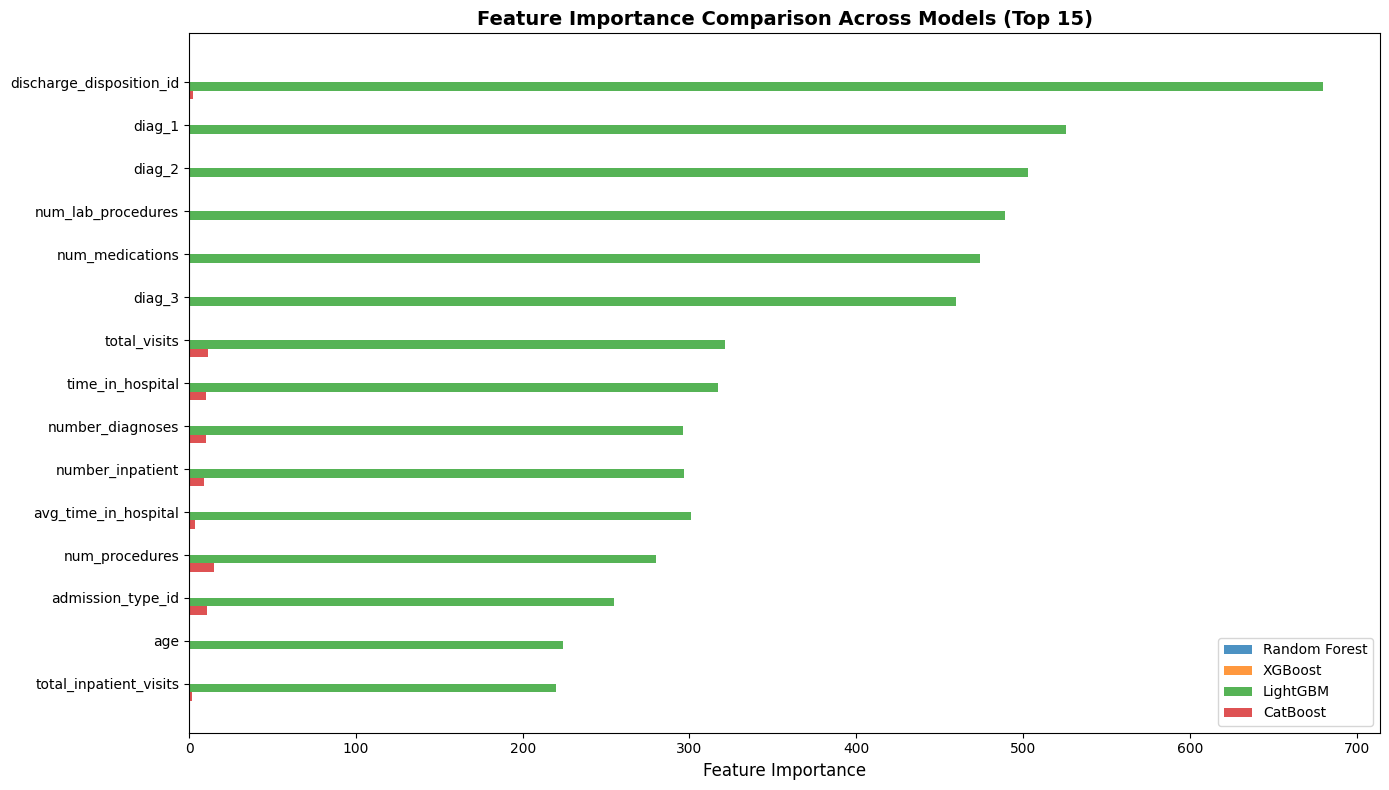


SHAP INTERPRETABILITY ANALYSIS

SHAP (SHapley Additive exPlanations) provides model interpretability
by explaining individual predictions and overall feature importance.
This is especially valuable for clinical models where explainability is critical.

Using LightGBM for SHAP analysis...

Creating SHAP explainer...
Note: This may take a few minutes depending on model type and data size.
✅ Using TreeExplainer (fast and exact for tree models)

Calculating SHAP values for 500 validation samples...
✅ SHAP values calculated!

SHAP SUMMARY PLOT

This plot shows which features most impact readmission predictions.
Features are ranked by importance, and colors show feature values.
Red = high feature value, Blue = low feature value



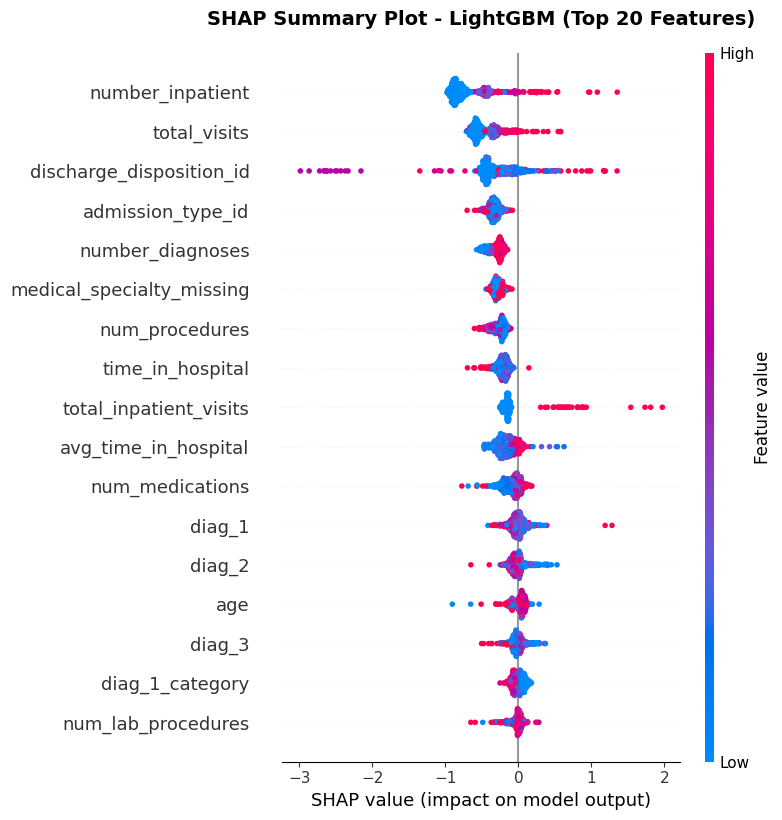


SHAP FEATURE IMPORTANCE (Bar Plot)

This shows the average absolute SHAP value for each feature.
Higher values = more important for predictions.



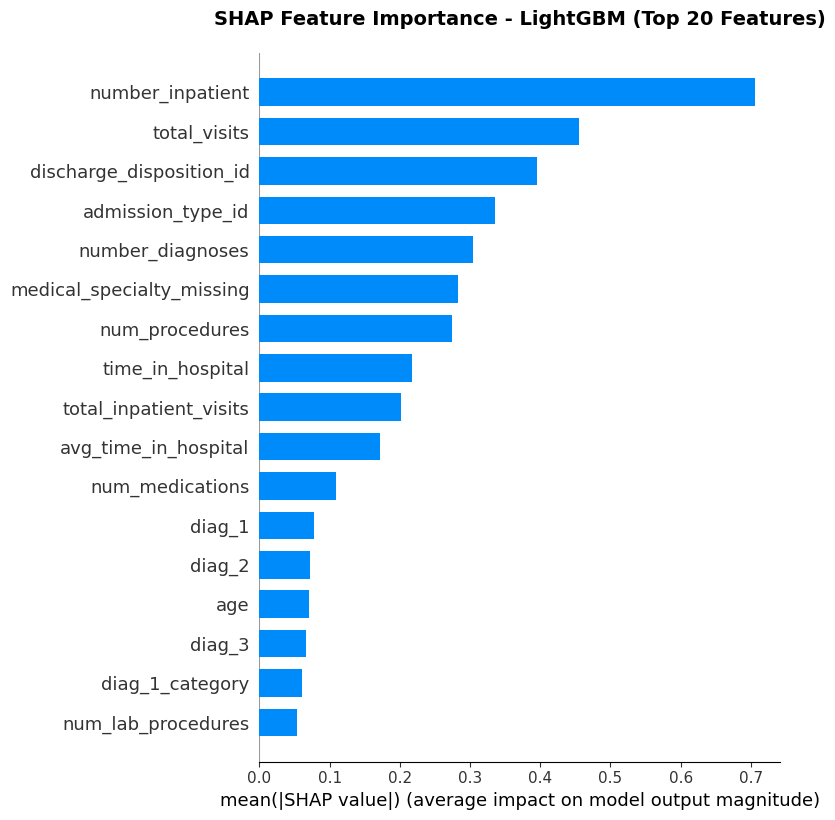


SHAP FEATURE IMPORTANCE RANKING

Top 20 Features by SHAP Importance:
                  feature  mean_abs_shap
         number_inpatient       0.706197
             total_visits       0.454942
 discharge_disposition_id       0.395509
        admission_type_id       0.336073
         number_diagnoses       0.304896
medical_specialty_missing       0.283420
           num_procedures       0.274227
         time_in_hospital       0.217523
   total_inpatient_visits       0.201428
     avg_time_in_hospital       0.172395
          num_medications       0.109369
                   diag_1       0.077225
                   diag_2       0.072734
                      age       0.070669
                   diag_3       0.066835
          diag_1_category       0.061206
       num_lab_procedures       0.053493

SHAP INDIVIDUAL PREDICTION EXPLANATIONS

Waterfall plots explain individual predictions.
Showing 3 example predictions (high, medium, low risk)...


Example 1: High Risk Patient
  Predicted p

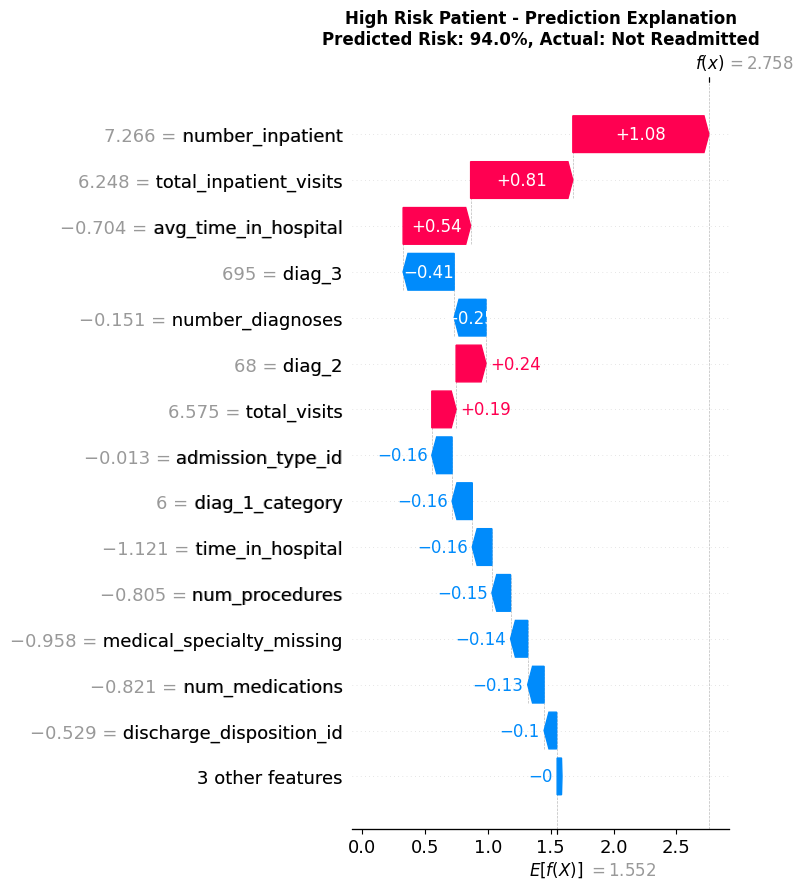


Example 2: Medium Risk Patient
  Predicted probability: 0.141
  Actual readmission: Unknown


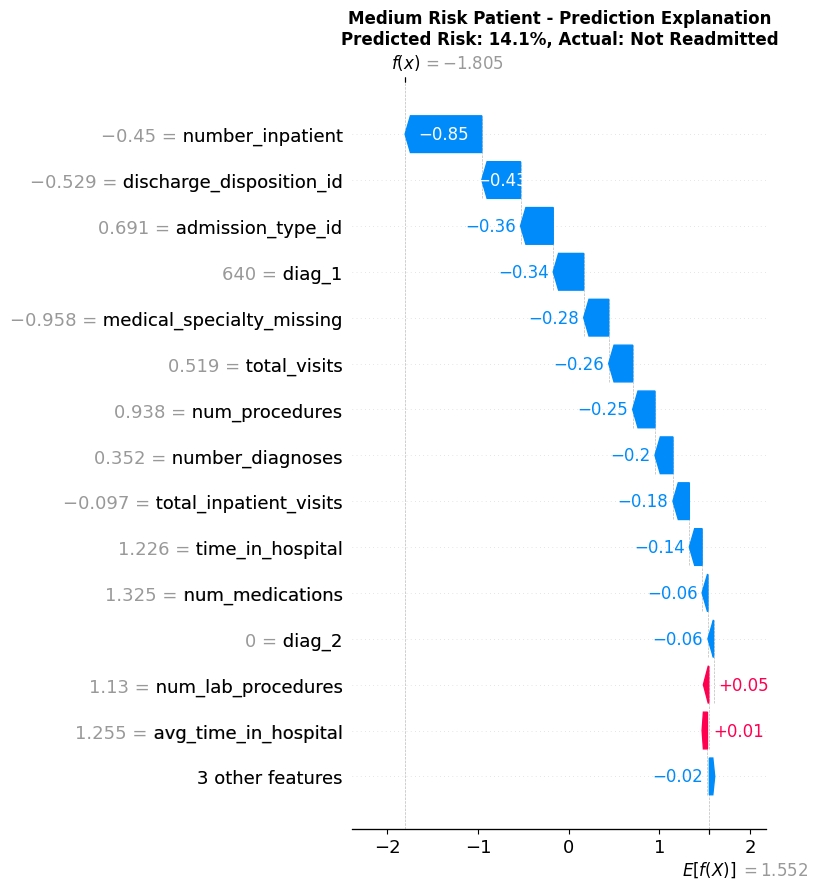


Example 3: Low Risk Patient
  Predicted probability: 0.011
  Actual readmission: Unknown


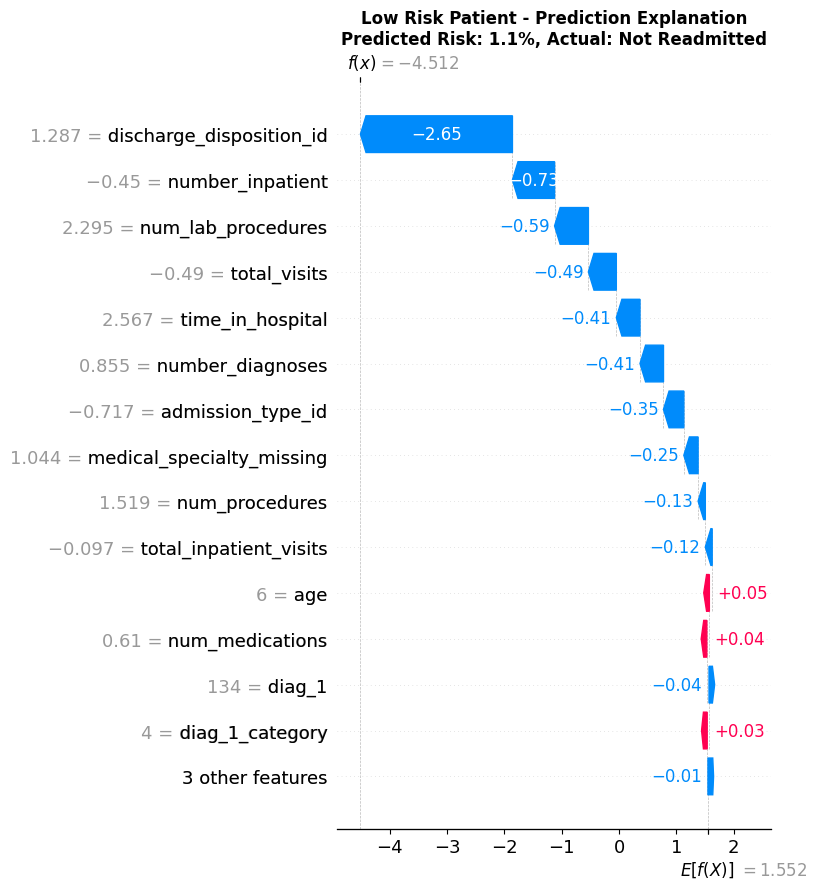


SHAP DEPENDENCE PLOTS (Top 5 Features)

Dependence plots show how a feature's value affects predictions.
Each point is a patient, colored by the most interacting feature.



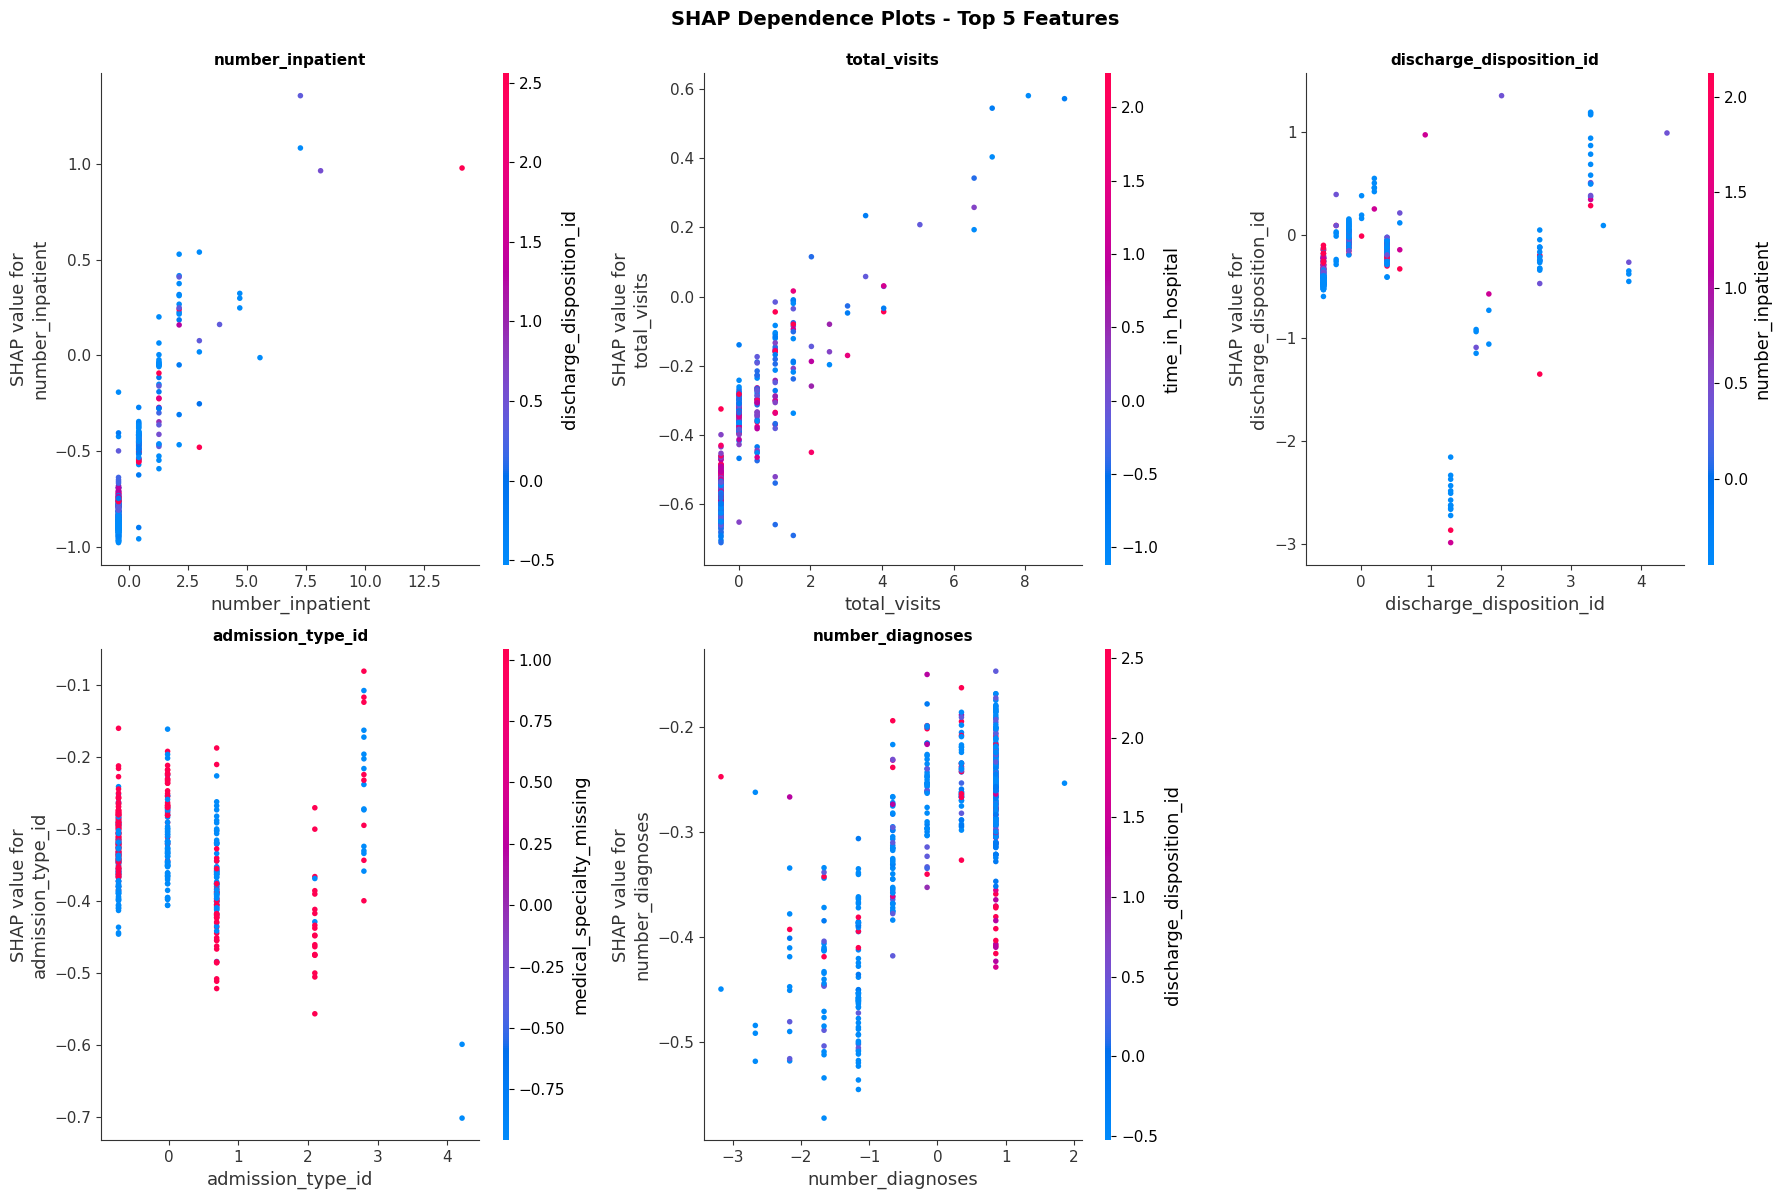


SHAP vs MODEL FEATURE IMPORTANCE COMPARISON

Top 15 Features - SHAP vs Model Importance:
                  feature  rank_shap  rank_model  shap_importance  model_importance
         number_inpatient        1.0        10.0         0.706197               297
             total_visits        2.0         7.0         0.454942               321
 discharge_disposition_id        3.0         1.0         0.395509               680
        admission_type_id        4.0        13.0         0.336073               255
         number_diagnoses        5.0        11.0         0.304896               296
medical_specialty_missing        6.0        17.0         0.283420               127
           num_procedures        7.0        12.0         0.274227               280
         time_in_hospital        8.0         8.0         0.217523               317
   total_inpatient_visits        9.0        15.0         0.201428               220
     avg_time_in_hospital       10.0         9.0         0.172395     

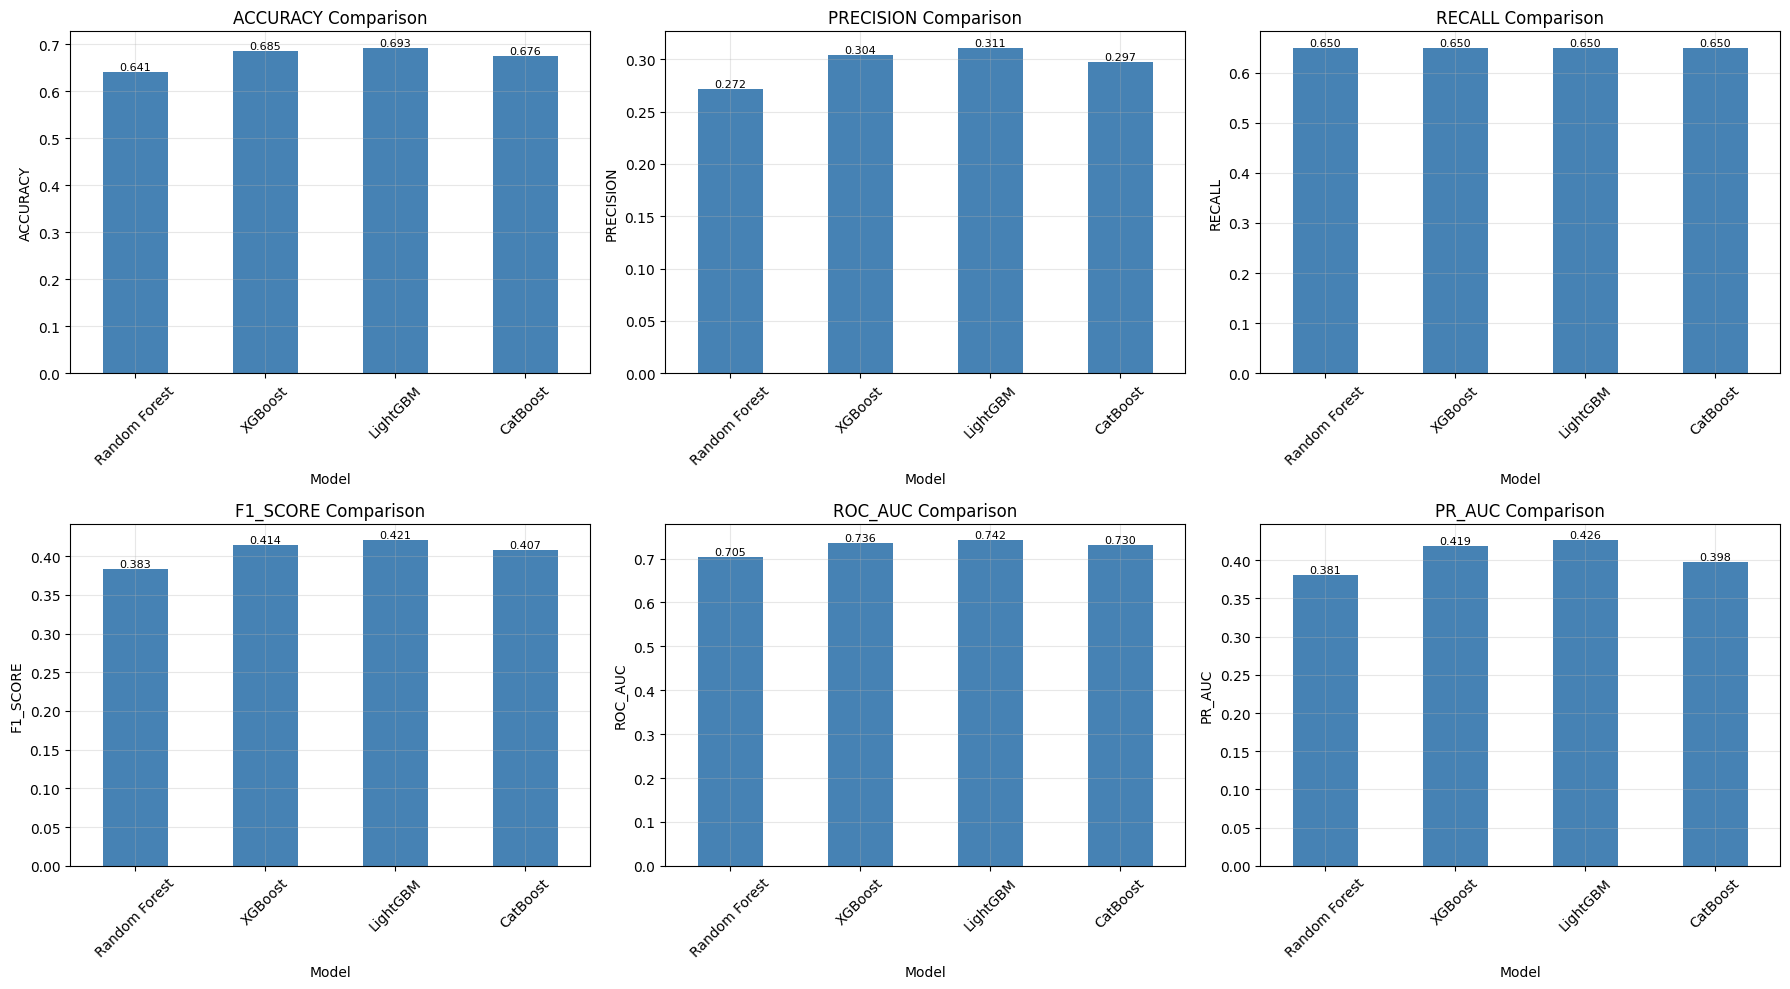


Model Performance Comparison:
               accuracy  precision  recall  f1_score  roc_auc  pr_auc
Random Forest    0.6409     0.2715  0.6499    0.3830   0.7045  0.3805
XGBoost          0.6851     0.3044  0.6499    0.4145   0.7358  0.4186
LightGBM         0.6930     0.3111  0.6499    0.4207   0.7419  0.4264
CatBoost         0.6758     0.2969  0.6499    0.4075   0.7303  0.3977

FINAL RESULTS SUMMARY

Best Model: LightGBM
Best Resampling: SMOTE
Feature Selection: Performed inside each CV fold (prevents data leakage)
Average Features Selected: 21.8 features per fold

SAVING RESULTS FOR FEATURE SELECTION ANALYSIS
✅ Results saved to: /content/drive/MyDrive/Colab Notebooks/Datasets/feature_selection_results.pkl

PART 1 COMPLETE - TRAINING AND CROSS-VALIDATION

You can now run PART 2 to analyze feature selection with different thresholds.
Part 2 can be run multiple times without retraining models.


In [ ]:
"""
Complete Diabetic Readmission Prediction Implementation for Google Colab
All code in one file - ready to run in Colab

================================================================================
CODE STRUCTURE - TWO PARTS:
================================================================================

PART 1: TRAINING AND CROSS-VALIDATION (Lines ~45-1160)
- Data loading, cleaning, feature engineering
- Model training with Group K-Fold CV
- Feature selection inside each fold
- Saves results to pickle file
- Run this ONCE (takes ~25-50 minutes)

PART 2: FEATURE SELECTION ANALYSIS (Lines ~1163-1336)
- Loads saved results from Part 1
- Frequency-based consensus feature selection
- Adjustable threshold (change threshold variable)
- Can run MULTIPLE TIMES with different thresholds
- Fast execution (~10 seconds)

USAGE:
1. Run entire file first time (Part 1 + Part 2)
2. To experiment with different thresholds:
   - Change 'threshold' variable around line 1204
   - Re-run only Part 2 (from line 1163 onwards)
   - No need to retrain models!
"""

# ============================================================================
# STEP 1: INSTALL AND IMPORT LIBRARIES
# ============================================================================

# Install required packages
!pip install -q lightgbm catboost optuna imbalanced-learn shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, average_precision_score, precision_recall_curve,
    confusion_matrix, classification_report
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN

# Gradient Boosting
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# SHAP for interpretability
import shap
shap.initjs()  # Initialize JavaScript visualization

# Ensemble (removed StackingClassifier - not needed)
# from sklearn.ensemble import StackingClassifier, VotingClassifier

print("All libraries imported successfully!")

# ============================================================================
# STEP 2: MOUNT GOOGLE DRIVE (if needed)
# ============================================================================

from google.colab import drive
drive.mount('/content/drive')

# ============================================================================
# STEP 3: FEATURE ENGINEERING FUNCTIONS
# ============================================================================

def extract_icd9_category(code):
    """Extract ICD-9 category from diagnosis code."""
    if pd.isna(code) or code == '?' or code == 'dummy' or code == '':
        return 'Unknown'

    try:
        code_str = str(code).replace('V', '').replace('E', '')
        code_num = float(code_str)

        if 1 <= code_num <= 139:
            return 'Infectious'
        elif 140 <= code_num <= 239:
            return 'Neoplasms'
        elif 240 <= code_num <= 279:
            return 'Endocrine'
        elif 280 <= code_num <= 289:
            return 'Blood'
        elif 290 <= code_num <= 319:
            return 'Mental'
        elif 320 <= code_num <= 389:
            return 'Nervous'
        elif 390 <= code_num <= 459:
            return 'Circulatory'
        elif 460 <= code_num <= 519:
            return 'Respiratory'
        elif 520 <= code_num <= 579:
            return 'Digestive'
        elif 580 <= code_num <= 629:
            return 'Genitourinary'
        elif 630 <= code_num <= 679:
            return 'Pregnancy'
        elif 680 <= code_num <= 709:
            return 'Skin'
        elif 710 <= code_num <= 739:
            return 'Musculoskeletal'
        elif 740 <= code_num <= 759:
            return 'Congenital'
        elif 760 <= code_num <= 779:
            return 'Perinatal'
        elif 780 <= code_num <= 799:
            return 'Symptoms'
        elif 800 <= code_num <= 999:
            return 'Injury'
        else:
            return 'Other'
    except (ValueError, AttributeError):
        return 'Unknown'


def create_patient_level_features(df):
    """Create patient-level aggregated features using only PAST encounters (prevents data leakage)."""
    df = df.copy()

    # Sort by patient_nbr (and encounter_id if it exists, otherwise use index)
    if 'encounter_id' in df.columns:
        df = df.sort_values(['patient_nbr', 'encounter_id'])
    else:
        # If encounter_id was dropped, use index as proxy for encounter order
        df = df.sort_values(['patient_nbr']).reset_index(drop=True)

    # Calculate previous readmissions excluding current encounter
    df['previous_readmissions'] = df.groupby('patient_nbr')['readmitted'].apply(
        lambda x: (x == '<30').shift(1).fillna(0).cumsum()
    ).values

    # Total encounters up to current (including current)
    df['total_encounters'] = df.groupby('patient_nbr').cumcount() + 1

    # CRITICAL FIX: Use expanding window to calculate statistics from PAST encounters only
    # This prevents data leakage by only using encounters before the current one
    def calculate_past_stats(group):
        """Calculate statistics using only past encounters (expanding window)."""
        result = pd.DataFrame(index=group.index)

        # Average time in hospital from PAST encounters only (shift(1) excludes current)
        result['avg_time_in_hospital'] = (
            group['time_in_hospital']
            .expanding(min_periods=1)
            .mean()
            .shift(1)
            .fillna(group['time_in_hospital'])  # For first encounter, use current value
        )

        # Total visits from PAST encounters only (shift(1) excludes current)
        result['total_inpatient_visits'] = (
            group['number_inpatient']
            .expanding(min_periods=1)
            .sum()
            .shift(1)
            .fillna(0)  # For first encounter, no past visits
        )

        result['total_outpatient_visits'] = (
            group['number_outpatient']
            .expanding(min_periods=1)
            .sum()
            .shift(1)
            .fillna(0)
        )

        result['total_emergency_visits'] = (
            group['number_emergency']
            .expanding(min_periods=1)
            .sum()
            .shift(1)
            .fillna(0)
        )

        return result

    # Apply expanding window calculation per patient
    patient_stats = df.groupby('patient_nbr', group_keys=False).apply(calculate_past_stats)

    # Merge the calculated statistics back to the dataframe
    df = df.join(patient_stats)

    df['is_repeat_patient'] = (df['total_encounters'] > 1).astype(int)

    # Ensure no NaN values remain (safety check)
    df['avg_time_in_hospital'] = df['avg_time_in_hospital'].fillna(df['time_in_hospital'])
    df['total_inpatient_visits'] = df['total_inpatient_visits'].fillna(0)
    df['total_outpatient_visits'] = df['total_outpatient_visits'].fillna(0)
    df['total_emergency_visits'] = df['total_emergency_visits'].fillna(0)

    return df


def create_icd9_features(df, top_n=7):
    """Create ICD-9 diagnosis category features - only TOP N most common categories."""
    df = df.copy()

    df['diag_1_category'] = df['diag_1'].apply(extract_icd9_category)
    df['diag_2_category'] = df['diag_2'].apply(extract_icd9_category)
    df['diag_3_category'] = df['diag_3'].apply(extract_icd9_category)

    # Only create features for TOP N most common categories (not all)
    top_categories = df['diag_1_category'].value_counts().head(top_n).index.tolist()

    for category in top_categories:
        if category != 'Unknown':
            df[f'has_{category.lower().replace(" ", "_")}'] = (
                (df['diag_1_category'] == category) |
                (df['diag_2_category'] == category) |
                (df['diag_3_category'] == category)
            ).astype(int)

    # Count unique categories (useful feature)
    df['num_diag_categories'] = df[['diag_1_category', 'diag_2_category', 'diag_3_category']].apply(
        lambda x: len(set(x) - {'Unknown'}), axis=1
    )

    return df


def create_missing_indicators(df):
    """Create missing value indicators."""
    df = df.copy()
    missing_cols = ['max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code']

    for col in missing_cols:
        if col in df.columns:
            is_missing = df[col].isna() | (df[col] == '?')
            df[f'{col}_missing'] = is_missing.astype(int)

    return df


def create_utilization_features(df):
    """Create essential hospital utilization features (minimal set)."""
    df = df.copy()

    # Essential: total visits
    df['total_visits'] = df['number_inpatient'] + df['number_outpatient'] + df['number_emergency']

    # Remove redundant intensity features - tree models can learn these patterns automatically
    # Keeping only the most essential one if needed
    # df['visit_intensity'] = df['total_visits'] / (df['time_in_hospital'] + 1)  # Optional

    return df


def create_interaction_features(df):
    """Skip interaction features - tree models (RF, XGBoost, LightGBM) handle interactions automatically."""
    # Tree-based models can learn interactions through their splitting mechanism
    # Creating explicit interaction features is redundant and can lead to overfitting
    return df


def apply_all_feature_engineering(df):
    """Apply selective feature engineering steps (only essential features)."""
    print("Applying selective feature engineering...")

    print("  - Creating patient-level features (CRITICAL - previous_readmissions is strongest predictor)...")
    df = create_patient_level_features(df)

    print("  - Creating top ICD-9 diagnosis categories (top 7 only, not all)...")
    df = create_icd9_features(df, top_n=7)

    print("  - Creating missing value indicators...")
    df = create_missing_indicators(df)

    print("  - Creating essential utilization features...")
    df = create_utilization_features(df)

    print("  - Skipping interaction features (tree models handle interactions automatically)...")
    df = create_interaction_features(df)

    print("Feature engineering complete!")
    return df

# ============================================================================
# STEP 4: EVALUATION FUNCTIONS
# ============================================================================

def calculate_all_metrics(y_true, y_pred, y_pred_proba=None):
    """Calculate all evaluation metrics."""
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0),
    }

    if y_pred_proba is not None:
        try:
            metrics['roc_auc'] = roc_auc_score(y_true, y_pred_proba)
            metrics['pr_auc'] = average_precision_score(y_true, y_pred_proba)
        except ValueError:
            metrics['roc_auc'] = np.nan
            metrics['pr_auc'] = np.nan

    return metrics


def find_optimal_threshold_for_recall(y_true, y_pred_proba, target_recall=0.65):
    """
    Find optimal threshold to achieve target recall for clinical model.

    Args:
        y_true: True labels
        y_pred_proba: Predicted probabilities
        target_recall: Target recall value (default 0.65 = 65% for clinical use)

    Returns:
        optimal_threshold: Threshold that achieves target recall
        metrics_at_threshold: Metrics at optimal threshold
    """
    from sklearn.metrics import precision_recall_curve

    precision, recall, thresholds = precision_recall_curve(y_true, y_pred_proba)

    # Find threshold closest to target recall
    # If target recall not achievable, use threshold with highest recall
    if len(thresholds) == 0:
        optimal_threshold = 0.5
        idx = 0
    else:
        idx = np.argmin(np.abs(recall - target_recall))
        if idx >= len(thresholds):
            idx = len(thresholds) - 1
        optimal_threshold = thresholds[idx]

    # Calculate metrics at optimal threshold
    y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
    metrics_at_threshold = calculate_all_metrics(y_true, y_pred_optimal, y_pred_proba)
    metrics_at_threshold['optimal_threshold'] = optimal_threshold
    metrics_at_threshold['actual_recall'] = recall[idx] if idx < len(recall) else metrics_at_threshold['recall']

    return optimal_threshold, metrics_at_threshold


def create_evaluation_table(results_dict):
    """Create a comparison table of all model results."""
    df = pd.DataFrame(results_dict).T
    df = df.round(4)

    column_order = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc']
    df = df[[col for col in column_order if col in df.columns]]

    return df

# ============================================================================
# STEP 5: DATA LOADING
# ============================================================================

print("\n" + "="*80)
print("DATA LOADING")
print("="*80)

# UPDATE THIS PATH TO YOUR DATASET LOCATION
path = "/content/drive/MyDrive/Colab Notebooks/Datasets/diabetic_data.csv"
df = pd.read_csv(path)

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print(f"\nFirst few rows:")
df.head()

# ============================================================================
# STEP 6: DATA CLEANING
# ============================================================================

print("\n" + "="*80)
print("DATA CLEANING")
print("="*80)

print("Target variable distribution:")
print(df['readmitted'].value_counts())
print("\nTarget variable percentages:")
print(df['readmitted'].value_counts(normalize=True) * 100)

# Create binary target (<30 days readmission)
df['readmitted_binary'] = df['readmitted'].map({
    'NO': 0,
    '<30': 1,
    '>30': 0
})

print(f"\nBinary target distribution:")
print(df['readmitted_binary'].value_counts())
class_ratio = (df['readmitted_binary']==0).sum() / (df['readmitted_binary']==1).sum()
print(f"Class imbalance ratio: {class_ratio:.2f}:1 (will use for model weights)")

# Remove >30 days rows
df = df[df['readmitted'] != '>30'].copy()

# Replace "?" with NaN
df.replace("?", pd.NA, inplace=True)

# Drop columns (but keep encounter_id temporarily for patient-level features)
# We'll drop it after feature engineering
cols_to_drop = ['weight', 'payer_code']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f"\nAfter cleaning: {df.shape}")
print(f"Target distribution:")
print(df['readmitted_binary'].value_counts())

# ============================================================================
# STEP 7: FEATURE ENGINEERING
# ============================================================================

print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

df_engineered = apply_all_feature_engineering(df)

print(f"\nAfter feature engineering: {df_engineered.shape}")
print(f"New features created: {df_engineered.shape[1] - df.shape[1]}")

# Check patient-level features
if 'previous_readmissions' in df_engineered.columns:
    print("\nPatient-level features created successfully!")
    print(f"previous_readmissions correlation: {df_engineered['previous_readmissions'].corr(df_engineered['readmitted_binary']):.4f}")
    print(f"\nprevious_readmissions distribution:")
    print(df_engineered['previous_readmissions'].value_counts().head(10))

# ============================================================================
# STEP 8: REMOVE IRRELEVANT FEATURES
# ============================================================================

def remove_irrelevant_features(df, threshold_sparse=0.005, threshold_constant=0.99):
    """
    Remove irrelevant features based on sparsity and variance.

    Args:
        df: DataFrame with features
        threshold_sparse: Remove features where most common value appears in >threshold_constant of rows
        threshold_constant: Remove features where a single value appears >threshold_constant of rows

    Returns:
        DataFrame with irrelevant features removed, list of removed features
    """
    df = df.copy()
    removed_features = []

    # Identify categorical columns (object type)
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

    for col in categorical_cols:
        # Skip if already marked for removal
        if col in ['readmitted', 'readmitted_binary', 'encounter_id', 'patient_nbr']:
            continue

        # Check if feature is near-constant (one value dominates)
        value_counts = df[col].value_counts(normalize=True)
        if len(value_counts) > 0 and value_counts.iloc[0] > threshold_constant:
            removed_features.append((col, f'near-constant ({value_counts.iloc[0]:.2%} are "{value_counts.index[0]}")'))

    # Manually remove known sparse/irrelevant medication features based on literature
    # These medications are rarely prescribed or no longer used
    sparse_medications = [
        'examide',        # Extremely rare
        'citoglipton',    # Extremely rare
        'troglitazone',   # Withdrawn from market
        'acetohexamide',  # Rarely used
        'tolbutamide',    # Rarely used
        'miglitol',       # Rarely used
        'tolazamide',     # Rarely used
        'glimepiride-pioglitazone',  # Combination rarely used
        'metformin-rosiglitazone',   # Combination rarely used
        'metformin-pioglitazone'     # Combination rarely used
    ]

    for col in sparse_medications:
        if col in df.columns and col not in [f[0] for f in removed_features]:
            # Verify it's actually sparse before removing
            if col in categorical_cols:
                value_counts = df[col].value_counts(normalize=True)
                non_no_percentage = 1.0 - value_counts.get('No', 0.0) - value_counts.get('no', 0.0)
                if non_no_percentage < threshold_sparse:
                    removed_features.append((col, f'sparse medication (<{threshold_sparse:.1%} prescribed)'))

    # Remove the features
    features_to_drop = [f[0] for f in removed_features]
    df.drop(columns=features_to_drop, inplace=True, errors='ignore')

    return df, removed_features

print("\n" + "="*80)
print("REMOVING IRRELEVANT FEATURES")
print("="*80)

# Remove irrelevant features before modeling
df_cleaned, removed_features = remove_irrelevant_features(df_engineered)

if removed_features:
    print(f"\nRemoved {len(removed_features)} irrelevant features:")
    for feat, reason in removed_features:
        print(f"  - {feat}: {reason}")
else:
    print("\nNo irrelevant features found to remove.")

print(f"\nDataset shape after removal: {df_cleaned.shape}")

# ============================================================================
# STEP 9: PREPARE DATA FOR MODELING
# ============================================================================

print("\n" + "="*80)
print("PREPARING DATA FOR MODELING")
print("="*80)

df_model = df_cleaned.copy()

# Separate features and target
# Drop encounter_id and patient_nbr now (after feature engineering is done)
# patient_nbr is only used for Group K-Fold grouping, not as a feature
X = df_model.drop(['readmitted', 'readmitted_binary', 'encounter_id', 'patient_nbr'], axis=1, errors='ignore')
y = df_model['readmitted_binary']
groups = df_model['patient_nbr'].values  # Keep for Group K-Fold grouping only

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Unique patients: {len(np.unique(groups))}")

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nCategorical columns: {len(categorical_cols)}")
print(f"Numerical columns: {len(numerical_cols)}")

# ============================================================================
# STEP 10: PREPROCESSING FUNCTION
# ============================================================================

def preprocess_data(X_train, X_test, categorical_cols, numerical_cols):
    """Preprocess data inside CV loop to prevent data leakage."""
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()

    # Handle missing values in categorical columns
    for col in categorical_cols:
        if col in X_train_processed.columns:
            mode_val = X_train_processed[col].mode()
            if len(mode_val) > 0:
                X_train_processed[col].fillna(mode_val[0], inplace=True)
                X_test_processed[col].fillna(mode_val[0], inplace=True)
            else:
                X_train_processed[col].fillna('Unknown', inplace=True)
                X_test_processed[col].fillna('Unknown', inplace=True)

    # Handle missing values in numerical columns
    for col in numerical_cols:
        if col in X_train_processed.columns:
            median_val = X_train_processed[col].median()
            X_train_processed[col].fillna(median_val, inplace=True)
            X_test_processed[col].fillna(median_val, inplace=True)

    # Label encode categorical variables
    label_encoders = {}
    for col in categorical_cols:
        if col in X_train_processed.columns:
            le = LabelEncoder()
            X_train_processed[col] = le.fit_transform(X_train_processed[col].astype(str))

            # Better handling of unseen categories in test set
            test_values = X_test_processed[col].astype(str)
            unseen_mask = ~test_values.isin(le.classes_)
            if unseen_mask.any():
                # Map unseen values to most common class (or first class)
                most_common_class = le.classes_[0]  # Use first class as default
                test_values.loc[unseen_mask] = most_common_class
            X_test_processed[col] = le.transform(test_values)
            label_encoders[col] = le

    # Scale numerical features
    scaler = StandardScaler()
    if len(numerical_cols) > 0:
        num_cols_present = [col for col in numerical_cols if col in X_train_processed.columns]
        if len(num_cols_present) > 0:
            X_train_scaled = scaler.fit_transform(X_train_processed[num_cols_present])
            X_test_scaled = scaler.transform(X_test_processed[num_cols_present])
            X_train_processed[num_cols_present] = X_train_scaled
            X_test_processed[num_cols_present] = X_test_scaled

    # FINAL SAFEGUARD: Ensure all data is numeric (prevents string conversion issues)
    for col in X_train_processed.columns:
        if X_train_processed[col].dtype == 'object':
            X_train_processed[col] = pd.to_numeric(X_train_processed[col], errors='coerce').fillna(0)
        if X_test_processed[col].dtype == 'object':
            X_test_processed[col] = pd.to_numeric(X_test_processed[col], errors='coerce').fillna(0)

    # Ensure no NaN or Inf values remain
    X_train_processed = X_train_processed.replace([np.inf, -np.inf], 0).fillna(0)
    X_test_processed = X_test_processed.replace([np.inf, -np.inf], 0).fillna(0)

    return X_train_processed, X_test_processed, label_encoders, scaler


def select_features_forward_selection(X_train_proc, y_train, groups_train, resampler,
                                      max_features=50, n_splits=3, quick_model=None):
    """
    Perform forward feature selection on training data only (prevents data leakage).

    Args:
        X_train_proc: Preprocessed training features
        y_train: Training target
        groups_train: Patient groups for Group K-Fold
        resampler: Resampling strategy
        max_features: Maximum number of features to test
        n_splits: Number of folds for internal CV
        quick_model: Model to use for feature selection (default: RandomForest)

    Returns:
        selected_feature_names: List of selected feature names
        best_n_features: Optimal number of features
    """
    from sklearn.feature_selection import mutual_info_classif

    # Calculate class ratio for feature selection models
    class_ratio_fs = (y_train == 0).sum() / (y_train == 1).sum()

    if quick_model is None:
        quick_model = RandomForestClassifier(
            n_estimators=50, max_depth=10, random_state=42, n_jobs=-1,
            class_weight='balanced'  # Add class weights for clinical recall
        )

    # Get feature importance from multiple models on training data only
    feature_importance_models = {
        'RF': RandomForestClassifier(
            n_estimators=100, max_depth=10, random_state=42, n_jobs=-1,
            class_weight='balanced'  # Add class weights for clinical recall
        ),
        'XGB': xgb.XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1,
            scale_pos_weight=class_ratio_fs  # Add class weights for clinical recall
        ),
        'LGBM': lgb.LGBMClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1,
            class_weight='balanced'  # Add class weights for clinical recall
        )
    }

    feature_scores = pd.DataFrame({
        'feature': X_train_proc.columns
    })

    # Resample training data for feature importance calculation
    X_train_resampled, y_train_resampled = resampler.fit_resample(X_train_proc, y_train)

    # Get importance from each model
    for name, model in feature_importance_models.items():
        model.fit(X_train_resampled, y_train_resampled)

        if hasattr(model, 'feature_importances_'):
            feature_scores[f'{name}_importance'] = model.feature_importances_
        else:
            # Fallback: use mutual information
            mi_scores = mutual_info_classif(X_train_proc, y_train, random_state=42)
            feature_scores[f'{name}_importance'] = mi_scores

    # Aggregate importance scores (average across models)
    feature_scores['aggregate_score'] = feature_scores[[col for col in feature_scores.columns if 'importance' in col]].mean(axis=1)
    feature_scores = feature_scores.sort_values('aggregate_score', ascending=False)

    # Test different numbers of top features using internal CV
    feature_counts = list(range(5, min(max_features, len(feature_scores))+1, 2))
    if len(feature_scores) > max_features:
        feature_counts.append(len(feature_scores))

    best_n_features = None
    best_feature_score = 0
    feature_selection_results = {}
    selected_feature_names = None

    # Internal Group K-Fold for feature selection
    internal_kfold = GroupKFold(n_splits=n_splits)

    for n_features in feature_counts:
        scores = []
        top_features = feature_scores.head(n_features)['feature'].tolist()

        # Use Group K-Fold to prevent data leakage
        for train_idx, val_idx in internal_kfold.split(X_train_proc, y_train, groups_train):
            X_train_fold = X_train_proc.iloc[train_idx]
            X_val_fold = X_train_proc.iloc[val_idx]
            y_train_fold = y_train.iloc[train_idx]
            y_val_fold = y_train.iloc[val_idx]

            # Select only top N features
            X_train_selected = X_train_fold[top_features]
            X_val_selected = X_val_fold[top_features]

            # Resample
            X_train_resampled, y_train_resampled = resampler.fit_resample(X_train_selected, y_train_fold)

            # Train and evaluate
            quick_model.fit(X_train_resampled, y_train_resampled)
            y_pred_proba = quick_model.predict_proba(X_val_selected)[:, 1]
            score = roc_auc_score(y_val_fold, y_pred_proba)
            scores.append(score)

        avg_score = np.mean(scores)
        feature_selection_results[n_features] = avg_score

        if avg_score > best_feature_score:
            best_feature_score = avg_score
            best_n_features = n_features
            selected_feature_names = top_features.copy()

    return selected_feature_names, best_n_features, feature_selection_results

# ============================================================================
# STEP 11: GROUP K-FOLD SETUP
# ============================================================================

print("\n" + "="*80)
print("GROUP K-FOLD CROSS-VALIDATION SETUP")
print("="*80)

n_splits = 5
group_kfold = GroupKFold(n_splits=n_splits)

print(f"Using {n_splits}-fold Group K-Fold Cross-Validation")
print(f"This ensures patient-level separation (no data leakage)")

# ============================================================================
# STEP 12: RESAMPLING STRATEGY SELECTION
# ============================================================================

print("\n" + "="*80)
print("RESAMPLING STRATEGY SELECTION")
print("="*80)

resampling_strategies = {
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'SMOTEENN': SMOTEENN(random_state=42)
}

print("Testing resampling strategies...")
print("This may take a few minutes...\n")

best_resampler = None
best_score = 0
resampling_scores = {}

# FIX: Use full dataset or larger sample for better resampling strategy selection
# Use larger sample for faster computation while still being representative
sample_size = min(30000, len(X))
X_sample = X.iloc[:sample_size].copy()
y_sample = y.iloc[:sample_size].copy()
groups_sample = groups[:sample_size]

quick_kfold = GroupKFold(n_splits=3)

for name, resampler in resampling_strategies.items():
    scores = []
    print(f"Testing {name}...")

    for fold, (train_idx, val_idx) in enumerate(quick_kfold.split(X_sample, y_sample, groups_sample)):
        X_train_fold = X_sample.iloc[train_idx]
        X_val_fold = X_sample.iloc[val_idx]
        y_train_fold = y_sample.iloc[train_idx]
        y_val_fold = y_sample.iloc[val_idx]

        X_train_proc, X_val_proc, _, _ = preprocess_data(
            X_train_fold, X_val_fold, categorical_cols, numerical_cols
        )

        try:
            X_train_resampled, y_train_resampled = resampler.fit_resample(X_train_proc, y_train_fold)
            rf_quick = RandomForestClassifier(
                n_estimators=50, random_state=42, n_jobs=-1,
                class_weight='balanced'  # Add class weights for clinical recall
            )
            rf_quick.fit(X_train_resampled, y_train_resampled)
            y_pred_proba = rf_quick.predict_proba(X_val_proc)[:, 1]
            score = roc_auc_score(y_val_fold, y_pred_proba)
            scores.append(score)
        except Exception as e:
            print(f"  Error in fold {fold}: {e}")
            scores.append(0)

    avg_score = np.mean(scores)
    resampling_scores[name] = avg_score
    print(f"  {name} - Average ROC-AUC: {avg_score:.4f}")

    if avg_score > best_score:
        best_score = avg_score
        best_resampler = resampler

# For clinical model: Use SMOTE directly (better for recall than SMOTEENN)
# SMOTEENN was too conservative - removed too many positive samples
best_resampler = SMOTE(random_state=42)
print(f"\nUsing SMOTE resampling (optimized for clinical recall)")
print(f"Note: SMOTEENN was too conservative for clinical use - using SMOTE instead")

# ============================================================================
# STEP 13: MODEL-BASED FEATURE SELECTION (FORWARD SELECTION)
# ============================================================================

print("\n" + "="*80)
print("MODEL-BASED FEATURE SELECTION (FORWARD SELECTION)")
print("="*80)

print("NOTE: Feature selection will be performed INSIDE each CV fold")
print("      to prevent data leakage. This ensures that feature selection")
print("      only uses training data from each fold.\n")
print("      Feature selection uses forward selection with model-based")
print("      importance ranking from Random Forest, XGBoost, and LightGBM.\n")

# ============================================================================
# STEP 14: MODEL TRAINING
# ============================================================================

print("\n" + "="*80)
print("MODEL TRAINING WITH GROUP K-FOLD CROSS-VALIDATION")
print("="*80)

# Calculate class imbalance ratio for model weights
# Note: class_ratio was calculated earlier in data cleaning section
# If not available, calculate it here
if 'class_ratio' not in globals():
    class_ratio = (y == 0).sum() / (y == 1).sum()

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1,
        class_weight='balanced'  # Add class weights for clinical recall
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1,
        scale_pos_weight=class_ratio,  # Add class weights for clinical recall
        eval_metric='logloss'
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1,
        class_weight='balanced'  # Add class weights for clinical recall
    ),
    'CatBoost': cb.CatBoostClassifier(
        iterations=200, depth=6, learning_rate=0.1, random_state=42, verbose=False,
        class_weights=[1.0, class_ratio]  # Add class weights for clinical recall [neg, pos]
    )
}

all_results = {}
cv_results = {name: [] for name in models.keys()}

print("Training models with Group K-Fold Cross-Validation...")
print("Feature selection will be performed inside each fold to prevent data leakage.")
print("This will take some time...\n")

# Store feature selection results across folds for analysis
all_fold_feature_selections = []

for fold, (train_idx, val_idx) in enumerate(group_kfold.split(X, y, groups)):
    print(f"\nFold {fold + 1}/{n_splits}")
    print("-" * 60)

    X_train_fold = X.iloc[train_idx].copy()
    X_val_fold = X.iloc[val_idx].copy()
    y_train_fold = y.iloc[train_idx].copy()
    y_val_fold = y.iloc[val_idx].copy()
    groups_train_fold = groups[train_idx]

    # Preprocess
    X_train_proc, X_val_proc, _, _ = preprocess_data(
        X_train_fold, X_val_fold, categorical_cols, numerical_cols
    )

    # CRITICAL FIX: Perform feature selection INSIDE each CV fold (prevents data leakage)
    print(f"  Performing feature selection on training data (fold {fold + 1})...")
    selected_feature_names, best_n_features, feature_selection_results = select_features_forward_selection(
        X_train_proc, y_train_fold, groups_train_fold, best_resampler, max_features=50, n_splits=3
    )

    all_fold_feature_selections.append({
        'fold': fold + 1,
        'n_features': best_n_features,
        'features': selected_feature_names
    })

    print(f"  Selected {best_n_features} features for fold {fold + 1}")

    # Apply feature selection to both train and validation sets
    X_train_proc = X_train_proc[selected_feature_names]
    X_val_proc = X_val_proc[selected_feature_names]

    X_train_resampled, y_train_resampled = best_resampler.fit_resample(X_train_proc, y_train_fold)

    fold_results = {}
    for name, model in models.items():
        try:
            # Create fresh model instance for each fold with class weights
            if name == 'Random Forest':
                model_instance = RandomForestClassifier(
                    n_estimators=200, max_depth=10, random_state=42, n_jobs=-1,
                    class_weight='balanced'  # Add class weights for clinical recall
                )
            elif name == 'XGBoost':
                model_instance = xgb.XGBClassifier(
                    n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1,
                    scale_pos_weight=class_ratio,  # Add class weights for clinical recall
                    eval_metric='logloss'
                )
            elif name == 'LightGBM':
                model_instance = lgb.LGBMClassifier(
                    n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1,
                    class_weight='balanced'  # Add class weights for clinical recall
                )
            elif name == 'CatBoost':
                model_instance = cb.CatBoostClassifier(
                    iterations=200, depth=6, learning_rate=0.1, random_state=42, verbose=False,
                    class_weights=[1.0, class_ratio]  # Add class weights for clinical recall [neg, pos]
                )

            model_instance.fit(X_train_resampled, y_train_resampled)

            # Get probabilities
            y_pred_proba = model_instance.predict_proba(X_val_proc)[:, 1]

            # Find optimal threshold for recall (target 65% for clinical use)
            optimal_threshold, metrics_at_threshold = find_optimal_threshold_for_recall(
                y_val_fold, y_pred_proba, target_recall=0.65
            )

            # Use optimized threshold for predictions
            y_pred = (y_pred_proba >= optimal_threshold).astype(int)

            # Calculate metrics with optimized threshold
            metrics = calculate_all_metrics(y_val_fold, y_pred, y_pred_proba)
            metrics['optimal_threshold'] = optimal_threshold

            fold_results[name] = metrics
            cv_results[name].append(metrics)

            print(f"  {name:15s} - ROC-AUC: {metrics['roc_auc']:.4f}, "
                  f"Recall: {metrics['recall']:.4f}, F1: {metrics['f1_score']:.4f}, "
                  f"Threshold: {optimal_threshold:.3f}")

        except Exception as e:
            print(f"  {name:15s} - Error: {e}")

    all_results[f'fold_{fold+1}'] = fold_results

print("\n" + "="*60)
print("Cross-Validation Complete!")
print("="*60)

# ============================================================================
# STEP 15: CALCULATE AVERAGE METRICS
# ============================================================================

print("\n" + "="*80)
print("AVERAGE PERFORMANCE ACROSS FOLDS")
print("="*80)

avg_metrics = {}
for name in models.keys():
    if name in cv_results and len(cv_results[name]) > 0:
        avg_metrics[name] = {
            'accuracy': np.mean([m['accuracy'] for m in cv_results[name]]),
            'precision': np.mean([m['precision'] for m in cv_results[name]]),
            'recall': np.mean([m['recall'] for m in cv_results[name]]),
            'f1_score': np.mean([m['f1_score'] for m in cv_results[name]]),
            'roc_auc': np.mean([m['roc_auc'] for m in cv_results[name]]),
            'pr_auc': np.mean([m['pr_auc'] for m in cv_results[name]])
        }

        std_metrics = {
            'accuracy': np.std([m['accuracy'] for m in cv_results[name]]),
            'precision': np.std([m['precision'] for m in cv_results[name]]),
            'recall': np.std([m['recall'] for m in cv_results[name]]),
            'f1_score': np.std([m['f1_score'] for m in cv_results[name]]),
            'roc_auc': np.std([m['roc_auc'] for m in cv_results[name]]),
            'pr_auc': np.std([m['pr_auc'] for m in cv_results[name]])
        }

        print(f"\n{name}:")
        print(f"  Accuracy:  {avg_metrics[name]['accuracy']:.4f} (+/- {std_metrics['accuracy']:.4f})")
        print(f"  Precision: {avg_metrics[name]['precision']:.4f} (+/- {std_metrics['precision']:.4f})")
        print(f"  Recall:    {avg_metrics[name]['recall']:.4f} (+/- {std_metrics['recall']:.4f})")
        print(f"  F1-Score:  {avg_metrics[name]['f1_score']:.4f} (+/- {std_metrics['f1_score']:.4f})")
        print(f"  ROC-AUC:   {avg_metrics[name]['roc_auc']:.4f} (+/- {std_metrics['roc_auc']:.4f})")
        print(f"  PR-AUC:    {avg_metrics[name]['pr_auc']:.4f} (+/- {std_metrics['pr_auc']:.4f})")

comparison_df = create_evaluation_table(avg_metrics)
print("\n" + "="*60)
print("Model Comparison Table:")
print("="*60)
print(comparison_df.round(4))

# ============================================================================
# STEP 16: FEATURE IMPORTANCE COMPARISON
# ============================================================================

print("\n" + "="*80)
print("FEATURE IMPORTANCE COMPARISON ACROSS MODELS")
print("="*80)

best_model_name = max(avg_metrics.keys(), key=lambda x: avg_metrics[x]['roc_auc'])
print(f"Best model: {best_model_name} (ROC-AUC: {avg_metrics[best_model_name]['roc_auc']:.4f})")

# Train models on one fold to get feature importance
# Use the first fold's feature selection for consistency
train_idx, val_idx = next(group_kfold.split(X, y, groups))
X_train_final = X.iloc[train_idx].copy()
X_val_final = X.iloc[val_idx].copy()
y_train_final = y.iloc[train_idx].copy()
groups_train_final = groups[train_idx]

X_train_proc, X_val_proc, _, _ = preprocess_data(
    X_train_final, X_val_final, categorical_cols, numerical_cols
)

# Perform feature selection on this fold (for feature importance analysis)
print("Performing feature selection for feature importance analysis...")
selected_feature_names, best_n_features, _ = select_features_forward_selection(
    X_train_proc, y_train_final, groups_train_final, best_resampler, max_features=50, n_splits=3
)

# Apply feature selection
X_train_proc = X_train_proc[selected_feature_names]
X_val_proc = X_val_proc[selected_feature_names]

X_train_resampled, y_train_resampled = best_resampler.fit_resample(X_train_proc, y_train_final)

# Train all models and get feature importance
feature_importance_comparison = pd.DataFrame({
    'feature': selected_feature_names
})

for name, model_class in models.items():
    if name == 'Random Forest':
        model = RandomForestClassifier(
            n_estimators=200, max_depth=10, random_state=42, n_jobs=-1,
            class_weight='balanced'  # Add class weights for clinical recall
        )
    elif name == 'XGBoost':
        model = xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1,
            scale_pos_weight=class_ratio,  # Add class weights for clinical recall
            eval_metric='logloss'
        )
    elif name == 'LightGBM':
        model = lgb.LGBMClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1,
            class_weight='balanced'  # Add class weights for clinical recall
        )
    elif name == 'CatBoost':
        model = cb.CatBoostClassifier(
            iterations=200, depth=6, learning_rate=0.1, random_state=42, verbose=False,
            class_weights=[1.0, class_ratio]  # Add class weights for clinical recall [neg, pos]
        )

    model.fit(X_train_resampled, y_train_resampled)

    if hasattr(model, 'feature_importances_'):
        feature_importance_comparison[name] = model.feature_importances_

# Calculate consensus importance (average across models)
importance_cols = [col for col in feature_importance_comparison.columns if col != 'feature']
feature_importance_comparison['consensus'] = feature_importance_comparison[importance_cols].mean(axis=1)
feature_importance_comparison = feature_importance_comparison.sort_values('consensus', ascending=False)

print("\nTop 15 Features by Consensus Importance (across all models):")
print(feature_importance_comparison[['feature', 'consensus'] + importance_cols].head(15).round(4))

# Visualize feature importance comparison
plt.figure(figsize=(14, 8))
top_features = feature_importance_comparison.head(15)
x_pos = np.arange(len(top_features))

width = 0.2
for i, col in enumerate(importance_cols):
    plt.barh(x_pos + i*width, top_features[col], width, label=col, alpha=0.8)

plt.yticks(x_pos + width * (len(importance_cols)-1)/2, top_features['feature'])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Feature Importance Comparison Across Models (Top 15)', fontsize=14, fontweight='bold')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================================
# STEP 17: SHAP INTERPRETABILITY
# ============================================================================

print("\n" + "="*80)
print("SHAP INTERPRETABILITY ANALYSIS")
print("="*80)

print("\nSHAP (SHapley Additive exPlanations) provides model interpretability")
print("by explaining individual predictions and overall feature importance.")
print("This is especially valuable for clinical models where explainability is critical.\n")

# Use the best model (LightGBM) for SHAP analysis
print(f"Using {best_model_name} for SHAP analysis...")

# Train the best model on the selected features
if best_model_name == 'LightGBM':
    best_model = lgb.LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1,
        class_weight='balanced'
    )
elif best_model_name == 'XGBoost':
    best_model = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1,
        scale_pos_weight=class_ratio, eval_metric='logloss'
    )
elif best_model_name == 'CatBoost':
    best_model = cb.CatBoostClassifier(
        iterations=200, depth=6, learning_rate=0.1, random_state=42, verbose=False,
        class_weights=[1.0, class_ratio]
    )
else:  # Random Forest
    best_model = RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1,
        class_weight='balanced'
    )

# Fit the model
best_model.fit(X_train_resampled, y_train_resampled)

# Create SHAP explainer
print("\nCreating SHAP explainer...")
print("Note: This may take a few minutes depending on model type and data size.")

# Use TreeExplainer for tree-based models (faster and exact)
if best_model_name in ['LightGBM', 'XGBoost', 'CatBoost', 'Random Forest']:
    explainer = shap.TreeExplainer(best_model)
    print("✅ Using TreeExplainer (fast and exact for tree models)")
else:
    # Fallback to KernelExplainer for other models (slower)
    explainer = shap.KernelExplainer(best_model.predict_proba, X_train_resampled[:100])
    print("⚠️  Using KernelExplainer (slower, using sample of 100 instances)")

# Calculate SHAP values on a sample of validation data (for speed)
# Use up to 500 samples for SHAP analysis
n_shap_samples = min(500, len(X_val_proc))
shap_indices = np.random.choice(len(X_val_proc), n_shap_samples, replace=False)
X_val_shap = X_val_proc.iloc[shap_indices]

print(f"\nCalculating SHAP values for {n_shap_samples} validation samples...")
shap_values = explainer.shap_values(X_val_shap)

# Handle binary classification (SHAP returns list for binary)
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # Use positive class SHAP values

print("✅ SHAP values calculated!")

# ============================================================================
# SHAP Summary Plot (Most Important Visualization)
# ============================================================================

print("\n" + "="*80)
print("SHAP SUMMARY PLOT")
print("="*80)
print("\nThis plot shows which features most impact readmission predictions.")
print("Features are ranked by importance, and colors show feature values.")
print("Red = high feature value, Blue = low feature value\n")

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_val_shap,
                 feature_names=selected_feature_names,
                 show=False, max_display=20)
plt.title(f'SHAP Summary Plot - {best_model_name} (Top 20 Features)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ============================================================================
# SHAP Summary Bar Plot (Feature Importance Ranking)
# ============================================================================

print("\n" + "="*80)
print("SHAP FEATURE IMPORTANCE (Bar Plot)")
print("="*80)
print("\nThis shows the average absolute SHAP value for each feature.")
print("Higher values = more important for predictions.\n")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_val_shap,
                 feature_names=selected_feature_names,
                 plot_type="bar", show=False, max_display=20)
plt.title(f'SHAP Feature Importance - {best_model_name} (Top 20 Features)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ============================================================================
# SHAP Feature Importance DataFrame
# ============================================================================

print("\n" + "="*80)
print("SHAP FEATURE IMPORTANCE RANKING")
print("="*80)

# Calculate mean absolute SHAP values
shap_importance = pd.DataFrame({
    'feature': selected_feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("\nTop 20 Features by SHAP Importance:")
print(shap_importance.head(20).to_string(index=False))

# ============================================================================
# SHAP Waterfall Plot for Individual Predictions (Sample)
# ============================================================================

print("\n" + "="*80)
print("SHAP INDIVIDUAL PREDICTION EXPLANATIONS")
print("="*80)
print("\nWaterfall plots explain individual predictions.")
print("Showing 3 example predictions (high, medium, low risk)...\n")

# Find examples: high risk, medium risk, low risk
y_pred_proba_sample = best_model.predict_proba(X_val_shap)[:, 1]
high_risk_idx = np.argmax(y_pred_proba_sample)
low_risk_idx = np.argmin(y_pred_proba_sample)
medium_risk_idx = np.argsort(y_pred_proba_sample)[len(y_pred_proba_sample) // 2]

example_indices = [high_risk_idx, medium_risk_idx, low_risk_idx]
example_labels = ['High Risk', 'Medium Risk', 'Low Risk']

for i, (idx, label) in enumerate(zip(example_indices, example_labels)):
    prob = y_pred_proba_sample[idx]
    # Get actual label from validation set
    actual_idx = shap_indices[idx]
    # Get actual label - need to use the validation set labels
    # Since we're using X_val_proc, we need y_val_final which should be available
    # If not available, we'll skip showing actual label
    try:
        actual = y_val_final.iloc[actual_idx]
        actual_label = 'Yes' if actual == 1 else 'No'
    except:
        actual_label = 'Unknown'

    print(f"\nExample {i+1}: {label} Patient")
    print(f"  Predicted probability: {prob:.3f}")
    print(f"  Actual readmission: {actual_label}")

    # Create waterfall plot
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
            data=X_val_shap.iloc[idx].values,
            feature_names=selected_feature_names
        ),
        show=False,
        max_display=15
    )
    plt.title(f'{label} Patient - Prediction Explanation\n'
              f'Predicted Risk: {prob:.1%}, Actual: {"Readmitted" if actual_label == "Yes" else "Not Readmitted"}',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ============================================================================
# SHAP Dependence Plots for Top Features
# ============================================================================

print("\n" + "="*80)
print("SHAP DEPENDENCE PLOTS (Top 5 Features)")
print("="*80)
print("\nDependence plots show how a feature's value affects predictions.")
print("Each point is a patient, colored by the most interacting feature.\n")

top_5_features = shap_importance.head(5)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(top_5_features):
    if i < len(axes):
        ax = axes[i]
        feature_idx = selected_feature_names.index(feature)

        # Find most interacting feature
        interaction_idx = np.abs(shap_values[:, feature_idx]).argmax()

        shap.dependence_plot(
            feature_idx, shap_values, X_val_shap,
            feature_names=selected_feature_names,
            ax=ax, show=False
        )
        ax.set_title(f'{feature}', fontsize=11, fontweight='bold')

# Remove extra subplot
if len(top_5_features) < len(axes):
    fig.delaxes(axes[len(top_5_features)])

plt.suptitle('SHAP Dependence Plots - Top 5 Features',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ============================================================================
# Compare SHAP with Feature Importance
# ============================================================================

print("\n" + "="*80)
print("SHAP vs MODEL FEATURE IMPORTANCE COMPARISON")
print("="*80)

# Get model feature importance
if hasattr(best_model, 'feature_importances_'):
    model_importance = pd.DataFrame({
        'feature': selected_feature_names,
        'model_importance': best_model.feature_importances_
    }).sort_values('model_importance', ascending=False)

    # Merge with SHAP importance
    comparison = pd.merge(
        shap_importance.rename(columns={'mean_abs_shap': 'shap_importance'}),
        model_importance,
        on='feature',
        how='inner'
    )
    comparison['rank_shap'] = comparison['shap_importance'].rank(ascending=False)
    comparison['rank_model'] = comparison['model_importance'].rank(ascending=False)
    comparison = comparison.sort_values('shap_importance', ascending=False)

    print("\nTop 15 Features - SHAP vs Model Importance:")
    print(comparison.head(15)[['feature', 'rank_shap', 'rank_model',
                               'shap_importance', 'model_importance']].to_string(index=False))

    # Correlation between SHAP and model importance
    correlation = comparison['shap_importance'].corr(comparison['model_importance'])
    print(f"\nCorrelation between SHAP and Model Importance: {correlation:.3f}")

print("\n" + "="*80)
print("SHAP ANALYSIS COMPLETE")
print("="*80)
print("\nKey Insights:")
print("1. SHAP Summary Plot: Shows which features most impact readmission predictions")
print("2. SHAP Bar Plot: Ranks features by average importance")
print("3. Waterfall Plots: Explain individual patient predictions")
print("4. Dependence Plots: Show how feature values affect predictions")
print("\nThese visualizations are publication-ready and help explain model decisions!")

# ============================================================================
# STEP 18: ADDITIONAL VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("ADDITIONAL VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]

    if metric in comparison_df.columns:
        comparison_df[metric].plot(kind='bar', ax=ax, color='steelblue')
        ax.set_title(f'{metric.upper()} Comparison')
        ax.set_ylabel(metric.upper())
        ax.set_xlabel('Model')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)

        for i, v in enumerate(comparison_df[metric]):
            ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\nModel Performance Comparison:")
print(comparison_df.round(4))

# ============================================================================
# STEP 18: FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)

print(f"\nBest Model: {best_model_name}")
print(f"Best Resampling: {best_resampler.__class__.__name__}")
print(f"Feature Selection: Performed inside each CV fold (prevents data leakage)")
if all_fold_feature_selections:
    avg_n_features = np.mean([fs['n_features'] for fs in all_fold_feature_selections])
    print(f"Average Features Selected: {avg_n_features:.1f} features per fold")

# ============================================================================
# SAVE RESULTS FOR PART 2 (FEATURE SELECTION ANALYSIS)
# ============================================================================

print("\n" + "="*80)
print("SAVING RESULTS FOR FEATURE SELECTION ANALYSIS")
print("="*80)

import pickle
import os

# Save all necessary data for Part 2
results_to_save = {
    'all_fold_feature_selections': all_fold_feature_selections,
    'avg_metrics': avg_metrics,
    'best_model_name': best_model_name,
    'n_splits': n_splits,
    'X_columns': list(X.columns),  # Save original feature names
    'class_ratio': class_ratio
}

# Save to pickle file
save_path = '/content/drive/MyDrive/Colab Notebooks/Datasets/feature_selection_results.pkl'
try:
    with open(save_path, 'wb') as f:
        pickle.dump(results_to_save, f)
    print(f"✅ Results saved to: {save_path}")
except Exception as e:
    # If drive save fails, save locally
    save_path = '/content/feature_selection_results.pkl'
    with open(save_path, 'wb') as f:
        pickle.dump(results_to_save, f)
    print(f"✅ Results saved locally to: {save_path}")
    print(f"   (Note: This will be lost when Colab session ends)")

print("\n" + "="*80)
print("PART 1 COMPLETE - TRAINING AND CROSS-VALIDATION")
print("="*80)
print("\nYou can now run PART 2 to analyze feature selection with different thresholds.")
print("Part 2 can be run multiple times without retraining models.")



In [ ]:
# ============================================================================
# PART 2: FREQUENCY-BASED CONSENSUS FEATURE SELECTION FOR INFERENCE
# ============================================================================
# This section can be run independently after Part 1 completes
# Adjust the threshold variable below to experiment with different thresholds
# ============================================================================

print("\n" + "="*80)
print("PART 2: FREQUENCY-BASED CONSENSUS FEATURE SELECTION")
print("="*80)
print("\nLoading saved results from Part 1...")

# Load saved results
try:
    with open(save_path, 'rb') as f:
        saved_results = pickle.load(f)

    all_fold_feature_selections = saved_results['all_fold_feature_selections']
    avg_metrics = saved_results['avg_metrics']
    best_model_name = saved_results['best_model_name']
    n_splits = saved_results['n_splits']
    X_columns = saved_results['X_columns']
    class_ratio = saved_results['class_ratio']

    print("✅ Results loaded successfully!")
except Exception as e:
    print(f"⚠️  Could not load saved results: {e}")
    print("   Make sure Part 1 has completed successfully.")
    print("   If this is the first run, results will be saved at the end of Part 1.")
    raise

# ============================================================================
# ADJUSTABLE THRESHOLD FOR FEATURE SELECTION
# ============================================================================
# Change this value to experiment with different thresholds:
# - threshold = 2: More features (selected in ≥2/5 folds = 40%)
# - threshold = 3: Balanced (selected in ≥3/5 folds = 60%) [RECOMMENDED]
# - threshold = 4: Fewer features (selected in ≥4/5 folds = 80%)
# - threshold = 5: Most conservative (selected in all 5 folds = 100%)
# ============================================================================

threshold = 3  # ⬅️ CHANGE THIS VALUE TO EXPERIMENT WITH DIFFERENT THRESHOLDS

print(f"\n{'='*80}")
print(f"FEATURE SELECTION ANALYSIS (Threshold: ≥{threshold}/{n_splits} folds)")
print(f"{'='*80}")

# Count feature frequencies across folds
feature_counts = {}
feature_fold_map = {}  # Track which folds selected each feature

for fold_data in all_fold_feature_selections:
    fold_num = fold_data['fold']
    for feat in fold_data['features']:
        if feat not in feature_counts:
            feature_counts[feat] = 0
            feature_fold_map[feat] = []
        feature_counts[feat] += 1
        feature_fold_map[feat].append(fold_num)

# Sort features by frequency (most selected first)
feature_frequency_df = pd.DataFrame({
    'feature': list(feature_counts.keys()),
    'frequency': [feature_counts[f] for f in feature_counts.keys()],
    'folds': [sorted(feature_fold_map[f]) for f in feature_counts.keys()]
})
feature_frequency_df = feature_frequency_df.sort_values('frequency', ascending=False)

print(f"\nTotal unique features selected across all folds: {len(feature_counts)}")

# Show features selected per fold
print(f"\nFeatures selected per fold:")
for fold_data in all_fold_feature_selections:
    print(f"  Fold {fold_data['fold']}: {fold_data['n_features']} features")
    # Show first 10 features
    features_list = fold_data['features'][:10]
    print(f"    {', '.join(features_list)}")
    if len(fold_data['features']) > 10:
        print(f"    ... and {len(fold_data['features']) - 10} more")

print(f"\nFeature selection frequency distribution:")
frequency_dist = feature_frequency_df['frequency'].value_counts().sort_index(ascending=False)
for freq, count in frequency_dist.items():
    percentage = (freq / n_splits) * 100
    print(f"  Selected in {freq}/{n_splits} folds ({percentage:.0f}%): {count} features")

# Select features based on threshold (set above)
inference_features = feature_frequency_df[feature_frequency_df['frequency'] >= threshold]['feature'].tolist()

print(f"\n{'='*80}")
print(f"FINAL INFERENCE FEATURE SET (Frequency-Based Consensus)")
print(f"{'='*80}")
print(f"\nThreshold: Features selected in ≥{threshold}/{n_splits} folds (≥{threshold/n_splits*100:.0f}%)")
print(f"Final feature count: {len(inference_features)} features")
print(f"\nSelected features for inference:")
for i, feat in enumerate(inference_features, 1):
    freq = feature_counts[feat]
    folds = feature_fold_map[feat]
    print(f"  {i:2d}. {feat:30s} (selected in {freq}/{n_splits} folds: {folds})")

# Check custom features usage
print(f"\n{'='*80}")
print("CUSTOM FEATURES ANALYSIS")
print(f"{'='*80}")

custom_features = {
    'previous_readmissions': 'Patient-level: Previous readmission count',
    'total_encounters': 'Patient-level: Total encounters per patient',
    'avg_time_in_hospital': 'Patient-level: Average time in hospital',
    'total_inpatient_visits': 'Patient-level: Total inpatient visits',
    'total_outpatient_visits': 'Patient-level: Total outpatient visits',
    'total_emergency_visits': 'Patient-level: Total emergency visits',
    'is_repeat_patient': 'Patient-level: Repeat patient flag',
    'total_visits': 'Utilization: Total visits (inpatient + outpatient + emergency)',
    'num_diag_categories': 'ICD-9: Number of diagnosis categories',
}

print("\nCustom engineered features status:")
custom_selected = []
custom_not_selected = []

for feat_name, description in custom_features.items():
    if feat_name in feature_counts:
        freq = feature_counts[feat_name]
        folds = feature_fold_map[feat_name]
        in_inference = feat_name in inference_features
        status = "✅ SELECTED FOR INFERENCE" if in_inference else f"⚠️  Not selected (only {freq}/{n_splits} folds)"
        print(f"\n  {feat_name}:")
        print(f"    Description: {description}")
        print(f"    Frequency: {freq}/{n_splits} folds ({freq/n_splits*100:.0f}%)")
        print(f"    Folds: {folds}")
        print(f"    Status: {status}")
        if in_inference:
            custom_selected.append(feat_name)
        else:
            custom_not_selected.append(feat_name)
    else:
        print(f"\n  {feat_name}:")
        print(f"    Description: {description}")
        print(f"    Status: ❌ NOT SELECTED IN ANY FOLD")
        custom_not_selected.append(feat_name)

print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")
print(f"✅ Custom features selected for inference: {len(custom_selected)}/{len(custom_features)}")
if custom_selected:
    print(f"   Selected: {', '.join(custom_selected)}")
if custom_not_selected:
    print(f"   Not selected: {', '.join(custom_not_selected)}")

# Save inference features to a variable for easy access
print(f"\n{'='*80}")
print("INFERENCE FEATURE SET (READY TO USE)")
print(f"{'='*80}")
print(f"\nUse these {len(inference_features)} features for inference:")
print(f"inference_features = {inference_features}")
print(f"\nFeature count breakdown:")
print(f"  - Total features available: {len(X_columns)}")
print(f"  - Features selected in ≥{threshold} folds: {len(inference_features)}")
print(f"  - Features selected in all {n_splits} folds: {len(feature_frequency_df[feature_frequency_df['frequency'] == n_splits])}")

# Store for potential export
final_inference_features = inference_features.copy()

print(f"\n{'='*80}")
print("PART 2 COMPLETE - FEATURE SELECTION ANALYSIS")
print(f"{'='*80}")
print(f"\nTo try a different threshold, change the 'threshold' variable above and re-run Part 2.")
print(f"Current threshold: {threshold}/{n_splits} folds ({threshold/n_splits*100:.0f}%)")

print(f"\nAll Models Performance:")
for model_name, metrics in avg_metrics.items():
    print(f"\n{model_name}:")
    print(f"  ROC-AUC: {metrics['roc_auc']:.4f}")
    print(f"  F1-Score: {metrics['f1_score']:.4f}")
    print(f"  Accuracy: {metrics['accuracy']:.4f}")

print("\n" + "="*80)
print("Implementation Complete!")
print("="*80)





PART 2: FREQUENCY-BASED CONSENSUS FEATURE SELECTION

Loading saved results from Part 1...
✅ Results loaded successfully!

FEATURE SELECTION ANALYSIS (Threshold: ≥3/5 folds)

Total unique features selected across all folds: 29

Features selected per fold:
  Fold 1: 17 features
    discharge_disposition_id, diag_1, number_inpatient, number_diagnoses, total_visits, num_medications, num_lab_procedures, num_procedures, diag_3, diag_2
    ... and 7 more
  Fold 2: 25 features
    discharge_disposition_id, number_diagnoses, total_visits, diag_1, number_inpatient, num_lab_procedures, num_medications, avg_time_in_hospital, num_procedures, diag_3
    ... and 15 more
  Fold 3: 11 features
    discharge_disposition_id, number_diagnoses, diag_1, total_visits, number_inpatient, num_medications, diag_2, num_lab_procedures, time_in_hospital, num_procedures
    ... and 1 more
  Fold 4: 29 features
    discharge_disposition_id, number_diagnoses, total_visits, diag_1, number_inpatient, num_medications, d